In [1]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
import matplotlib.pyplot as plt
from bm3d import bm3d_rgb, BM3DProfile
import sys
module_dir = "/global/u2/k/kberard/SCGSR/Research/Diamond/stock_models/bm3d-4.0.3/bm3d-4.0.3/examples" 
sys.path.insert(0, module_dir)
from experiment_funcs import get_experiment_noise, get_psnr, get_cropped_psnr
from PIL import Image
import math
import torch
import torch.nn as nn
import torch.optim as optim
from thop import profile
from einops import rearrange 
from einops.layers.torch import Rearrange, Reduce
from timm.models.layers import trunc_normal_, DropPath

module_dir_scu = "/global/u2/k/kberard/SCGSR/Research/Diamond/stock_models/SCUNet" 
sys.path.insert(0, module_dir_scu)
from models.network_scunet import SCUNet as SCUNet
from torch.utils.data import Dataset
from utils import utils_image as util
import joblib
from sklearn.preprocessing import MinMaxScaler


2026-05-26 11:06:20.600411: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779818780.615522  945364 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779818780.620512  945364 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779818780.634388  945364 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779818780.634400  945364 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779818780.634402  945364 computation_placer.cc:177] computation placer alr

In [2]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
from bm3d import bm3d_rgb, BM3DProfile
import sys
from bm4d import bm4d, bm4d_multichannel, BM4DProfile, BM4DStages

In [3]:

with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_ref_mean.h5', 'r') as file:
    ref_d = file['density'][:]

In [4]:
#### test file #######
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000655360.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    test_d = file['density'][:]

In [5]:
def D_JS(p1,p2,tol=1e-16):
    p1= p1/np.sum(p1)
    p2=p2/np.sum(p2)
    pm = (p1+p2)/2
    p1_nonzero = np.abs(p1)>tol
    p2_nonzero = np.abs(p2)>tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5*( (p1*np.log(p1/pm1)).sum() + (p2*np.log(p2/pm2)).sum() )
    d /= np.log(2) # normalize to max of 1
    return d

In [6]:
def encode_voxel_to_rgb(test_d, save_path='slice_scalers.npz'):
    """
    Normalize each XY slice independently and encode to RGB (repeated channels).
    Saves (min, max) for each slice for reconstruction.
    
    Returns:
        rgb_volume: (64, 64, 64, 3)
    """
    rgb_volume = np.zeros((64, 64, 64, 3), dtype=np.float32)
    mins = []
    maxs = []

    for i in range(64):
        slice_2d = test_d[i, :, :]
        s_min = float(slice_2d.min())
        s_max = float(slice_2d.max())

        if s_max == s_min:
            s_max = s_min + 1e-6  # Avoid divide-by-zero for flat slices

        normed = (slice_2d - s_min) / (s_max - s_min)
        rgb_volume[i, :, :, :] = np.stack([normed]*3, axis=-1)  # (64, 64, 3)

        mins.append(s_min)
        maxs.append(s_max)

    np.savez(save_path, mins=np.array(mins), maxs=np.array(maxs))
    return rgb_volume  # shape: (64, 64, 64, 3)


In [7]:
def decode_rgb_to_voxel(rgb_volume, save_path='slice_scalers.npz'):
    """
    Decode per-slice normalized RGB volume back into scalar 3D volume.
    Assumes all RGB channels are identical.
    
    Args:
        rgb_volume: shape (64, 64, 64, 3)
    """
    data = np.load(save_path)
    mins = data['mins']
    maxs = data['maxs']

    test_d = np.zeros((64, 64, 64), dtype=np.float32)

    for i in range(64):
        rgb_slice = rgb_volume[i]  # (64, 64, 3)
        gray = rgb_slice[:, :, 0]
        restored = gray * (maxs[i] - mins[i]) + mins[i]
        test_d[i] = restored

    return test_d


In [8]:
print("enc dec loaded")

enc dec loaded


In [9]:
#Transform density
def transform(density,density_ref,transform_type):
    dens = density
    dref  = density_ref
    ttype = transform_type
    if ttype=='value':
        dtrans = density
    elif ttype=='sqrt':
        dtrans = np.sqrt(np.abs(density))
    elif ttype=='log':
        dtrans  = np.log(np.abs(density))
    elif ttype=='residual_noise':
        dval  = dref
        dsqrt = np.sqrt(np.abs(dref))
        dtrans = (dens-dval)/dsqrt
    else:
        raise RuntimeError('bad transform type')
    return dtrans


def inverse_transform(density_trans,density_ref,transform_type):
    dref   = density_ref
    ttype  = transform_type
    dtrans = density_trans
    if ttype=='value':
        density = dtrans
    elif ttype=='sqrt':
        density = dtrans**2
    elif ttype=='log':
        density = np.log(np.abs(dtrans))
    elif ttype=='residual_noise':
        dval  = dref
        dsqrt = np.sqrt(np.abs(dref))
        density = dval + dsqrt*dtrans
    else:
        raise RuntimeError('bad transform type')
    return density
dft_path ='/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_noJ/density_tot_ref.h5'
with h5py.File(dft_path, 'r') as file:
    dft_d = file['density'][:]

In [10]:
from bm3d import bm3d
def bm3d_test_pipeline(test_d, ref_d,dft_d,sample_count):
    # Encode
    test_d = transform(test_d,dft_d,'residual_noise')
    test_rgb = encode_voxel_to_rgb(test_d)
    ref_rgb  = encode_voxel_to_rgb(ref_d)

    # Denoise each of 64 RGB slices
    denoised_rgb = np.zeros_like(test_rgb)
    sigma = 0.000001 * np.sqrt(6881280 / sample_count)
    print("here")
    print(test_rgb.shape)



    #######
    for i in range(64):
        noisy_slice = test_rgb[i]

        gray_input = noisy_slice[:, :, 0]  # just one channel
        denoised_gray = bm3d(gray_input, sigma_psd=sigma)
        denoised_rgb[i] = np.stack([denoised_gray] * 3, axis=-1)

    ####

    # Reconstruct full 3D volume
    denoised_d = decode_rgb_to_voxel(denoised_rgb)
    denoised_d=inverse_transform(denoised_d,dft_d,'residual_noise')


    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 2D")
    jsd_noisy_2d = D_JS(test_d,
        ref_d
    )
    jsd_denoised_2d = D_JS(
        denoised_d,ref_d
    )

    norm_noisy_2d = np.linalg.norm(test_d - ref_d)
    norm_denoised_2d = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy_2d:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised_2d:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy_2d:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised_2d:.6f}")

    ##########
    # --- Evaluation ---
    print("\n>>> Evaluation Metrics 3D")
    jsd_noisy = D_JS(test_d,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")
    #########

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised_2d)

In [11]:
print("BM3D")

BM3D


In [12]:
from bm3d import bm3d
def bm4d_test_pipeline(test_d, ref_d,dft_d,sample_count):
    # Encode
    test_d_base = test_d.copy()
    test_d = transform(test_d,dft_d,'residual_noise')
    test_rgb = test_d
    ref_rgb  = ref_d
    print(sample_count)
    sigma_psd = 0.000001 * np.sqrt(6881280 / sample_count)
    # 3. Replace the model prediction line
    bm4d_raw = bm4d(test_d, sigma_psd)
    denoised_rgb =np.maximum(bm4d_raw, 0.0)
    



    # Reconstruct full 3D volume
    denoised_d = denoised_rgb
    denoised_d = inverse_transform(denoised_d,dft_d,'residual_noise')

    # --- Evaluation ---
    print("\n>>> Evaluation Metrics")
    jsd_noisy = D_JS(test_d_base,
        ref_d
    )
    jsd_denoised = D_JS(
        denoised_d,
        ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")

    print(test_d.shape,denoised_d.shape,ref_d.shape)

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised)

In [13]:
print("BM4D")

BM4D


In [14]:
def run_denoising_pipeline(noisy_path, ref_path, model_name, output_file='denoised_output.npy'):
    # convert h5 arrays 
    import h5py
    import numpy as np

    # Load data
    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]
    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]

    # Pick model pipeline
    if model_name == 'bm4d':
        denoised_density,jsd_denoised =bm4d_test_pipeline(test_d, ref_d,dft_d,sample_count)

    elif model_name == 'bm3d':
        denoised_density,jsd_denoised =bm3d_test_pipeline(test_d, ref_d,dft_d,sample_count)
    else:
        raise ValueError(f"Unsupported model name: {model_name}")

    # Save denoised result
    #np.save(output_file, denoised_density)
    print(f"\n Denoised matrix saved to {output_file}")
    return(denoised_density,jsd_denoised)


Found 33 noisy files.

=== Running model: bm4d ===
10240

>>> Evaluation Metrics
2-norm (noisy vs ref):     5.2365
2-norm (denoised vs ref): 0.0248
JSD   (noisy vs ref):     0.447456
JSD   (denoised vs ref):  0.073737
(64, 64, 64) (64, 64, 64) (64, 64, 64)


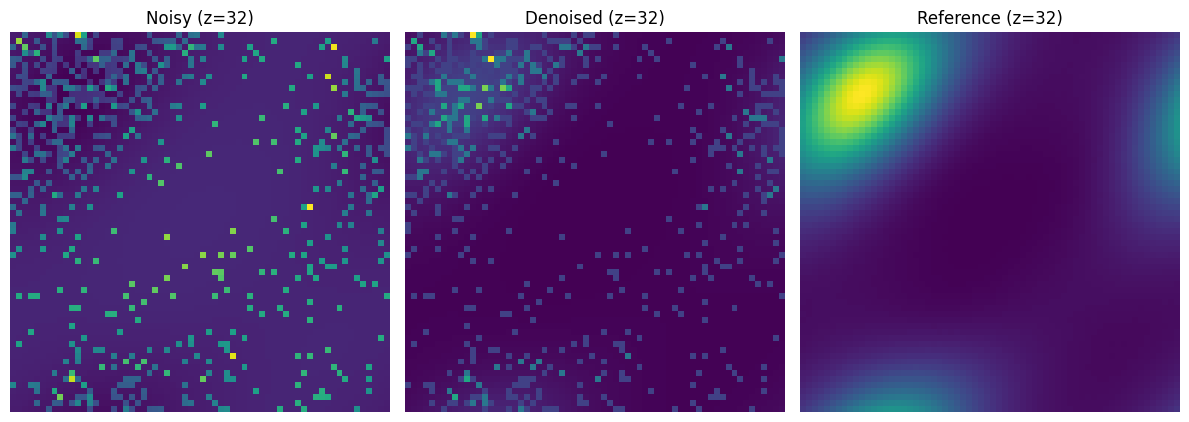


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000010240_bm4d_denoised.npy
Sample 10240 | bm4d JSD = 0.073737
20480

>>> Evaluation Metrics
2-norm (noisy vs ref):     3.7153
2-norm (denoised vs ref): 0.0168
JSD   (noisy vs ref):     0.292695
JSD   (denoised vs ref):  0.047663
(64, 64, 64) (64, 64, 64) (64, 64, 64)


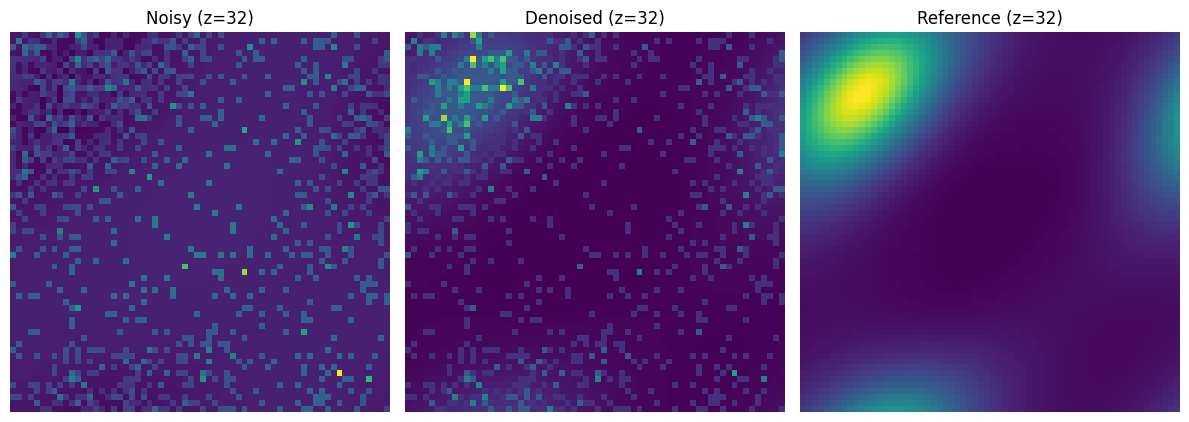


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000020480_bm4d_denoised.npy
Sample 20480 | bm4d JSD = 0.047663
40960

>>> Evaluation Metrics
2-norm (noisy vs ref):     2.6176
2-norm (denoised vs ref): 0.0114
JSD   (noisy vs ref):     0.169363
JSD   (denoised vs ref):  0.028819
(64, 64, 64) (64, 64, 64) (64, 64, 64)


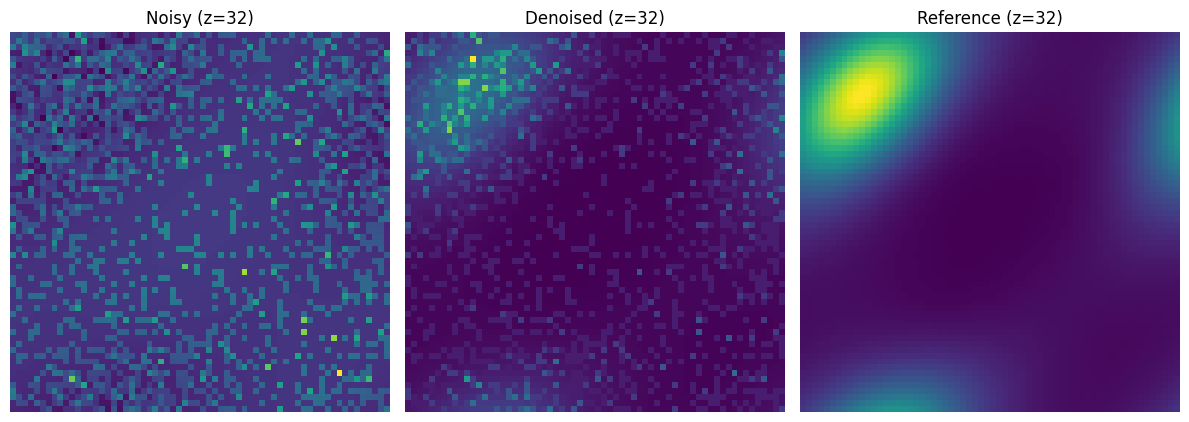


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000040960_bm4d_denoised.npy
Sample 40960 | bm4d JSD = 0.028819
81920

>>> Evaluation Metrics
2-norm (noisy vs ref):     1.8514
2-norm (denoised vs ref): 0.0078
JSD   (noisy vs ref):     0.090134
JSD   (denoised vs ref):  0.016566
(64, 64, 64) (64, 64, 64) (64, 64, 64)


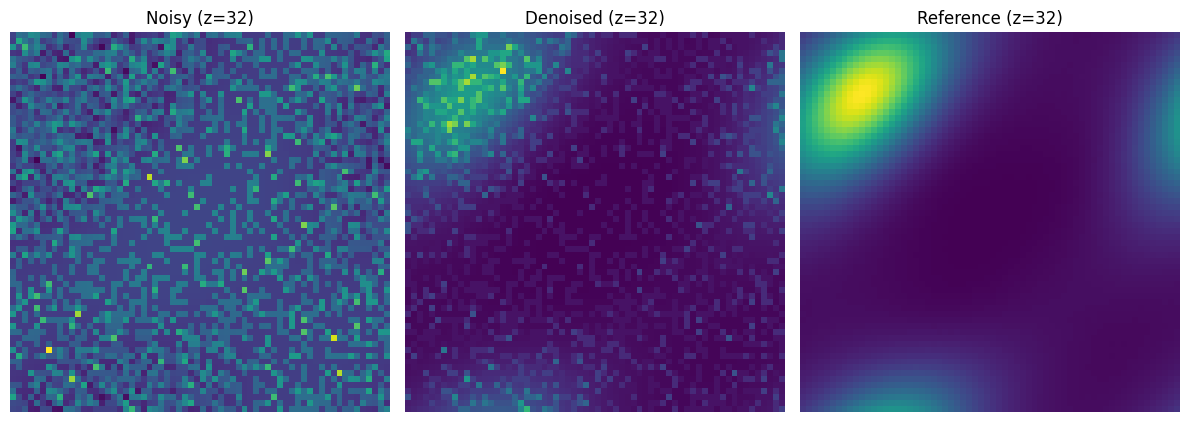


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000081920_bm4d_denoised.npy
Sample 81920 | bm4d JSD = 0.016566
163840

>>> Evaluation Metrics
2-norm (noisy vs ref):     1.3096
2-norm (denoised vs ref): 0.0054
JSD   (noisy vs ref):     0.044670
JSD   (denoised vs ref):  0.009386
(64, 64, 64) (64, 64, 64) (64, 64, 64)


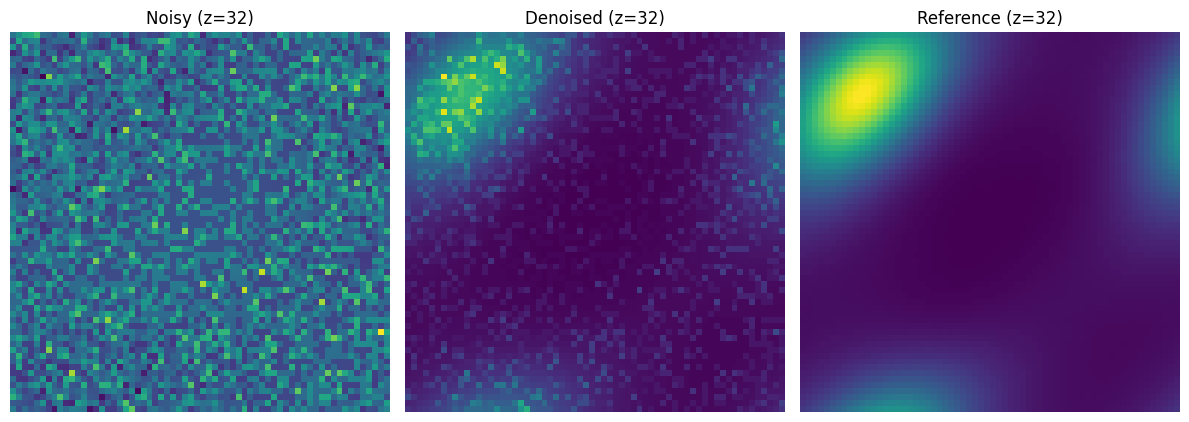


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000163840_bm4d_denoised.npy
Sample 163840 | bm4d JSD = 0.009386
327680

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.9276
2-norm (denoised vs ref): 0.0038
JSD   (noisy vs ref):     0.021160
JSD   (denoised vs ref):  0.005205
(64, 64, 64) (64, 64, 64) (64, 64, 64)


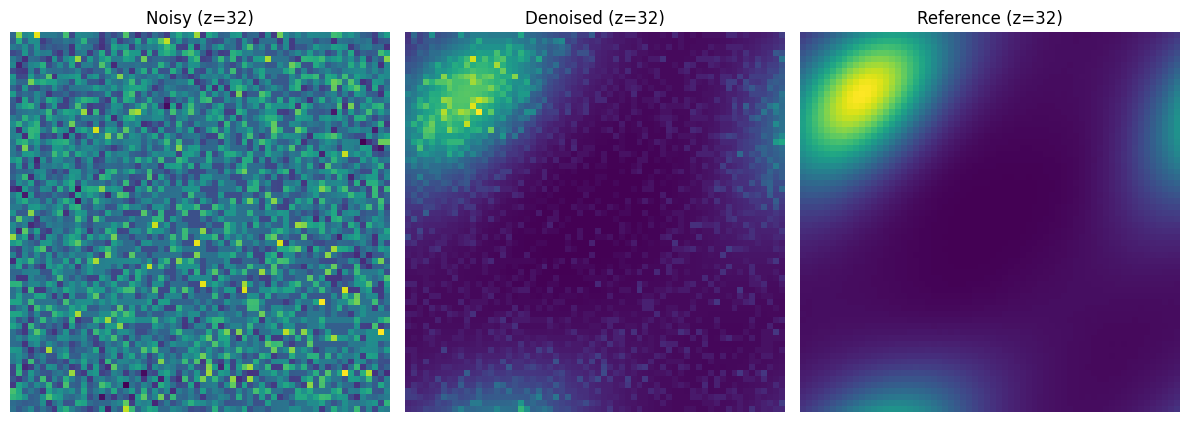


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000327680_bm4d_denoised.npy
Sample 327680 | bm4d JSD = 0.005205
430080

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.8108
2-norm (denoised vs ref): 0.0033
JSD   (noisy vs ref):     0.015750
JSD   (denoised vs ref):  0.004087
(64, 64, 64) (64, 64, 64) (64, 64, 64)


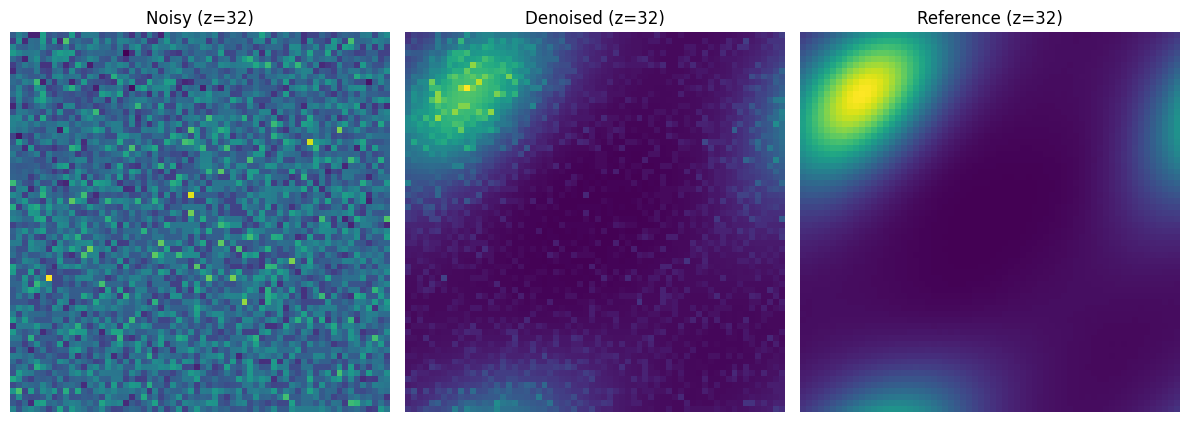


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000430080_bm4d_denoised.npy
Sample 430080 | bm4d JSD = 0.004087
655360

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.6583
2-norm (denoised vs ref): 0.0027
JSD   (noisy vs ref):     0.009959
JSD   (denoised vs ref):  0.002825
(64, 64, 64) (64, 64, 64) (64, 64, 64)


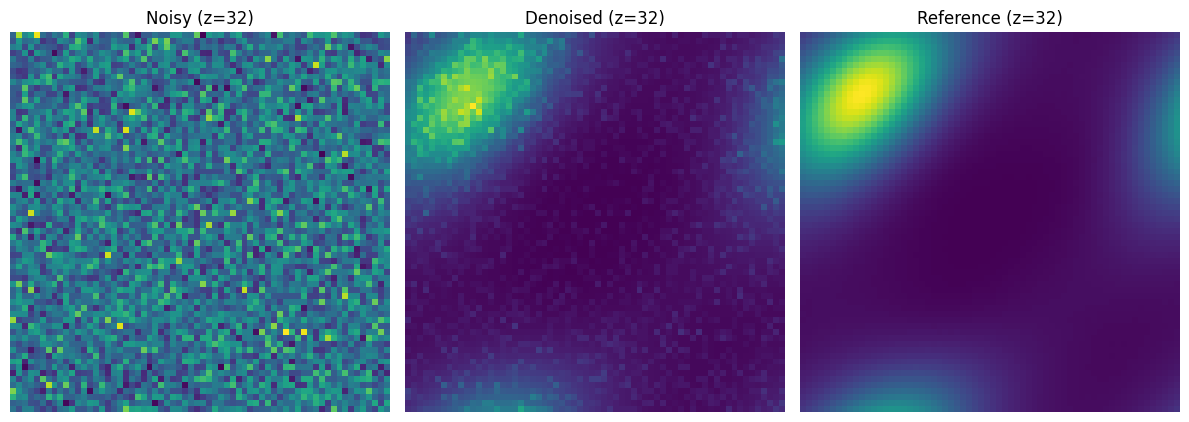


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000655360_bm4d_denoised.npy
Sample 655360 | bm4d JSD = 0.002825
860160

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.5753
2-norm (denoised vs ref): 0.0023
JSD   (noisy vs ref):     0.007447
JSD   (denoised vs ref):  0.002205
(64, 64, 64) (64, 64, 64) (64, 64, 64)


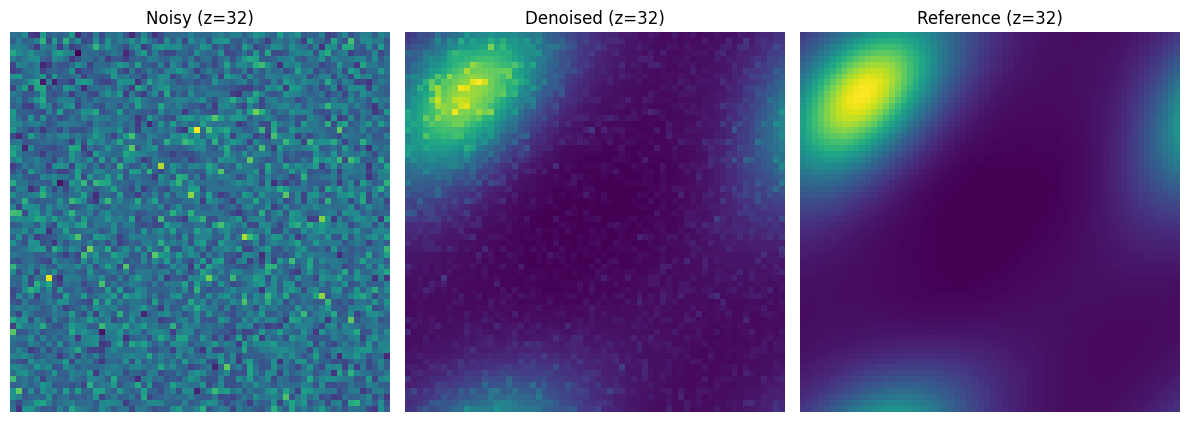


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000860160_bm4d_denoised.npy
Sample 860160 | bm4d JSD = 0.002205
1310720

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.4693
2-norm (denoised vs ref): 0.0019
JSD   (noisy vs ref):     0.004832
JSD   (denoised vs ref):  0.001510
(64, 64, 64) (64, 64, 64) (64, 64, 64)


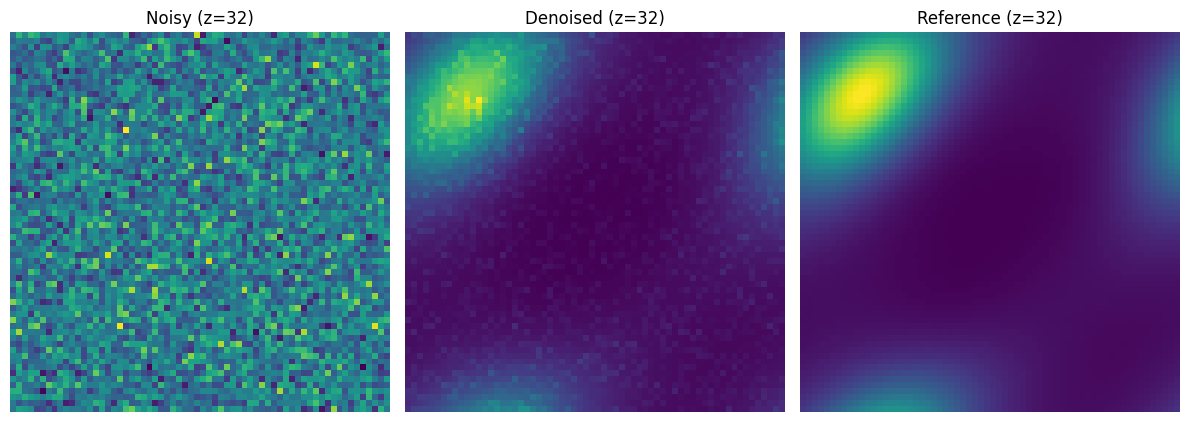


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0001310720_bm4d_denoised.npy
Sample 1310720 | bm4d JSD = 0.001510
1720320

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.4100
2-norm (denoised vs ref): 0.0017
JSD   (noisy vs ref):     0.003624
JSD   (denoised vs ref):  0.001172
(64, 64, 64) (64, 64, 64) (64, 64, 64)


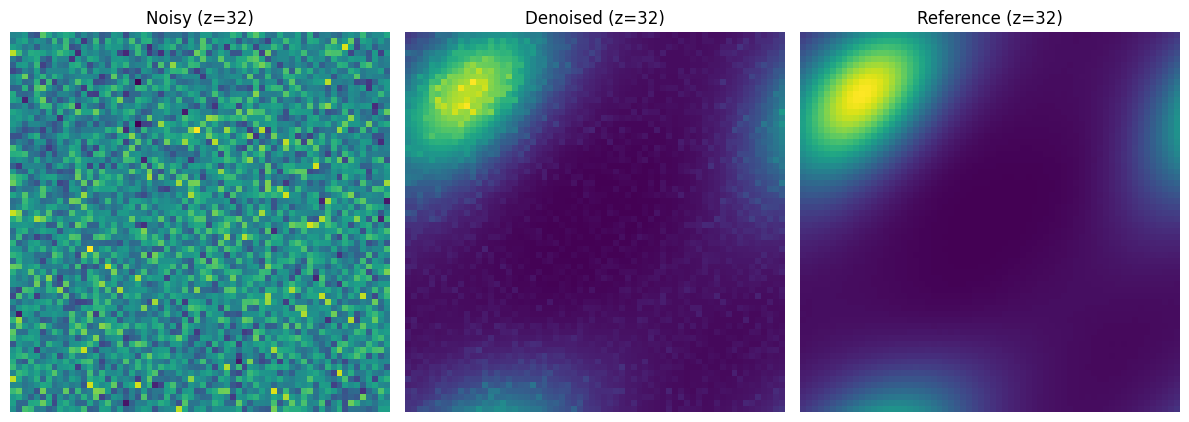


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0001720320_bm4d_denoised.npy
Sample 1720320 | bm4d JSD = 0.001172
2621440

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.3366
2-norm (denoised vs ref): 0.0014
JSD   (noisy vs ref):     0.002381
JSD   (denoised vs ref):  0.000804
(64, 64, 64) (64, 64, 64) (64, 64, 64)


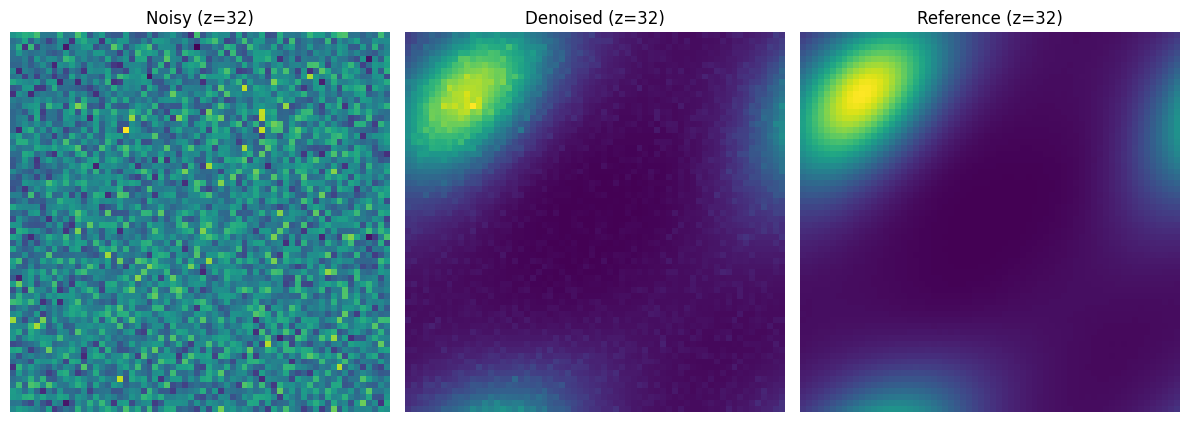


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0002621440_bm4d_denoised.npy
Sample 2621440 | bm4d JSD = 0.000804
3440640

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.2957
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.001797
JSD   (denoised vs ref):  0.000628
(64, 64, 64) (64, 64, 64) (64, 64, 64)


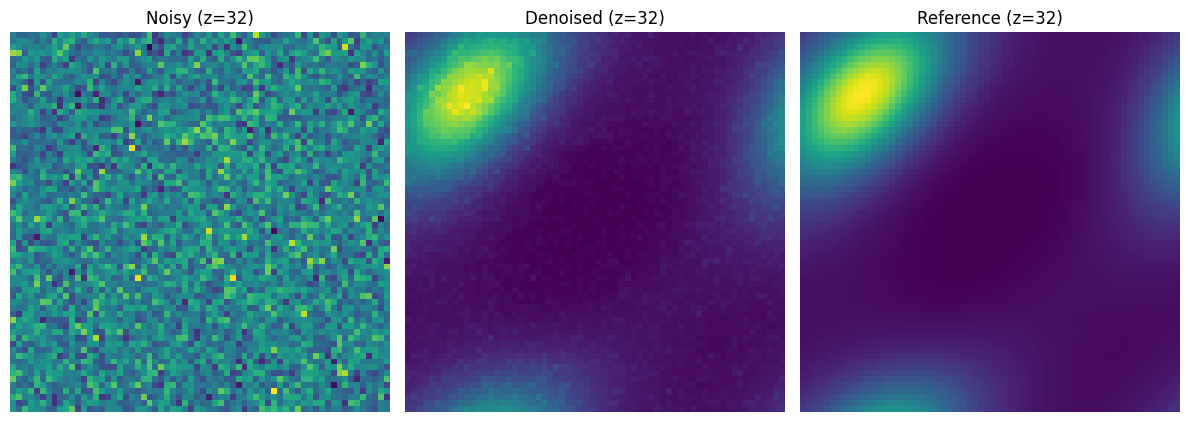


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0003440640_bm4d_denoised.npy
Sample 3440640 | bm4d JSD = 0.000628
5160960

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.2466
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.001203
JSD   (denoised vs ref):  0.000440
(64, 64, 64) (64, 64, 64) (64, 64, 64)


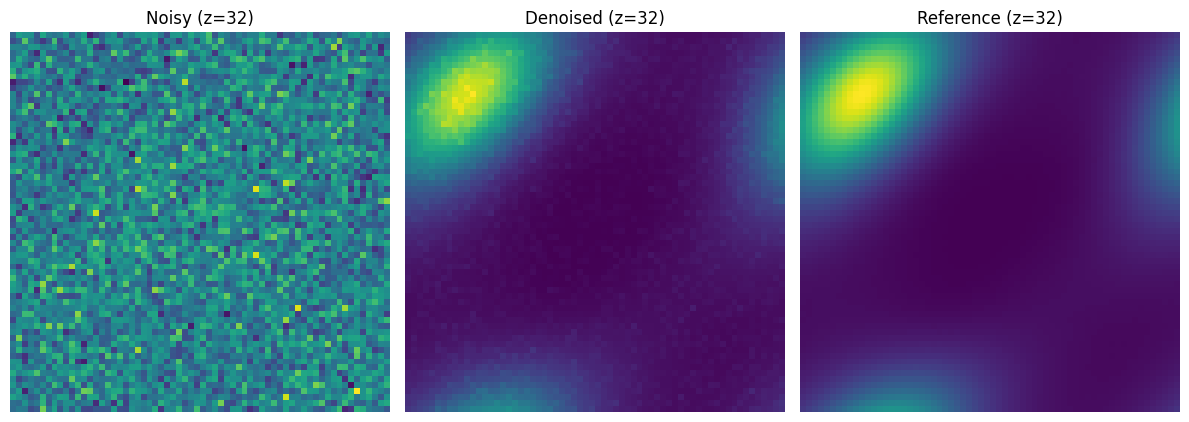


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0005160960_bm4d_denoised.npy
Sample 5160960 | bm4d JSD = 0.000440
5242880

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.2450
2-norm (denoised vs ref): 0.0010
JSD   (noisy vs ref):     0.001184
JSD   (denoised vs ref):  0.000434
(64, 64, 64) (64, 64, 64) (64, 64, 64)


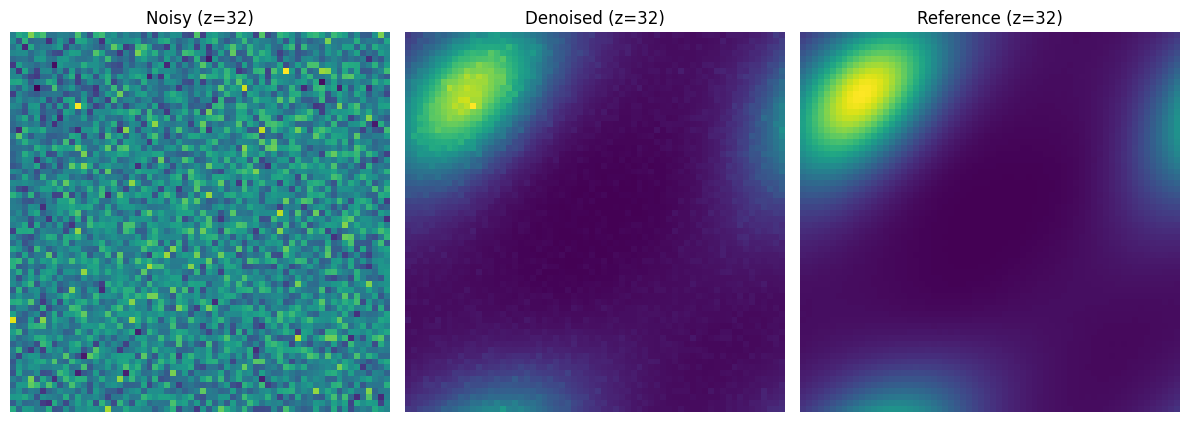


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0005242880_bm4d_denoised.npy
Sample 5242880 | bm4d JSD = 0.000434
6881280

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.2177
2-norm (denoised vs ref): 0.0009
JSD   (noisy vs ref):     0.000901
JSD   (denoised vs ref):  0.000344
(64, 64, 64) (64, 64, 64) (64, 64, 64)


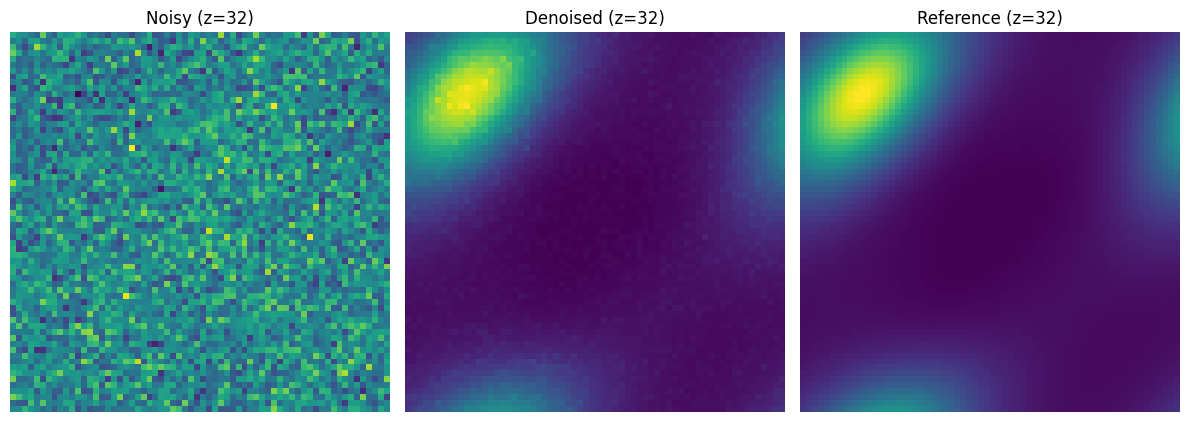


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0006881280_bm4d_denoised.npy
Sample 6881280 | bm4d JSD = 0.000344
10321920

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.1835
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000600
JSD   (denoised vs ref):  0.000245
(64, 64, 64) (64, 64, 64) (64, 64, 64)


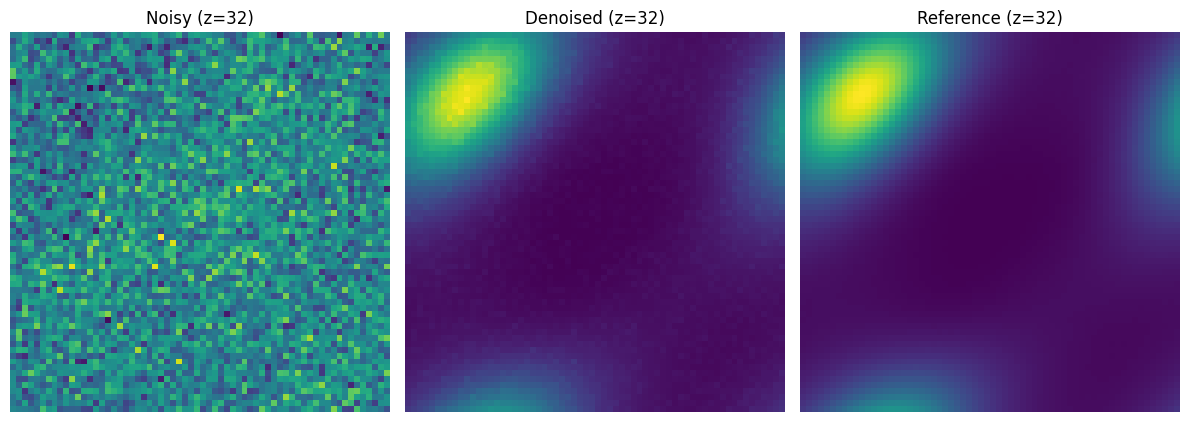


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0010321920_bm4d_denoised.npy
Sample 10321920 | bm4d JSD = 0.000245
10485760

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.1826
2-norm (denoised vs ref): 0.0008
JSD   (noisy vs ref):     0.000592
JSD   (denoised vs ref):  0.000243
(64, 64, 64) (64, 64, 64) (64, 64, 64)


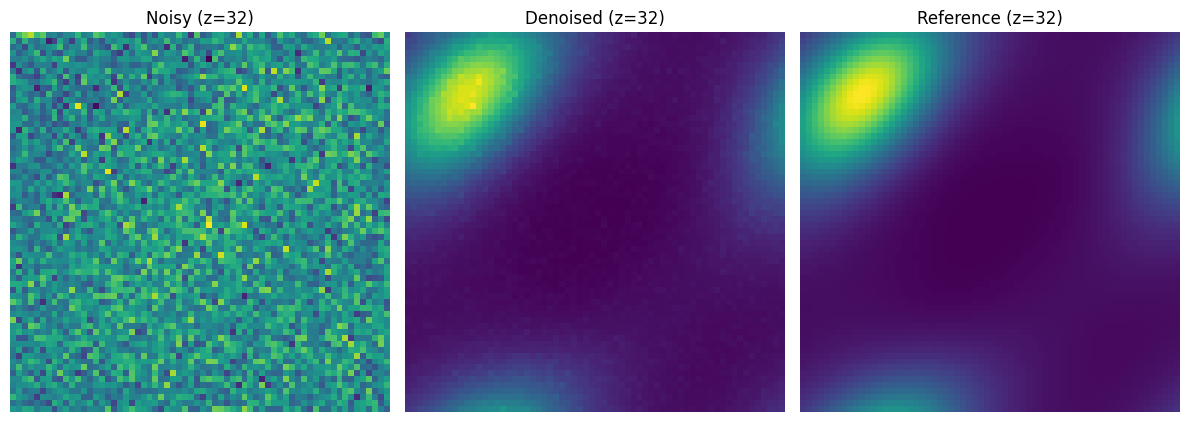


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0010485760_bm4d_denoised.npy
Sample 10485760 | bm4d JSD = 0.000243
13762560

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.1643
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000450
JSD   (denoised vs ref):  0.000196
(64, 64, 64) (64, 64, 64) (64, 64, 64)


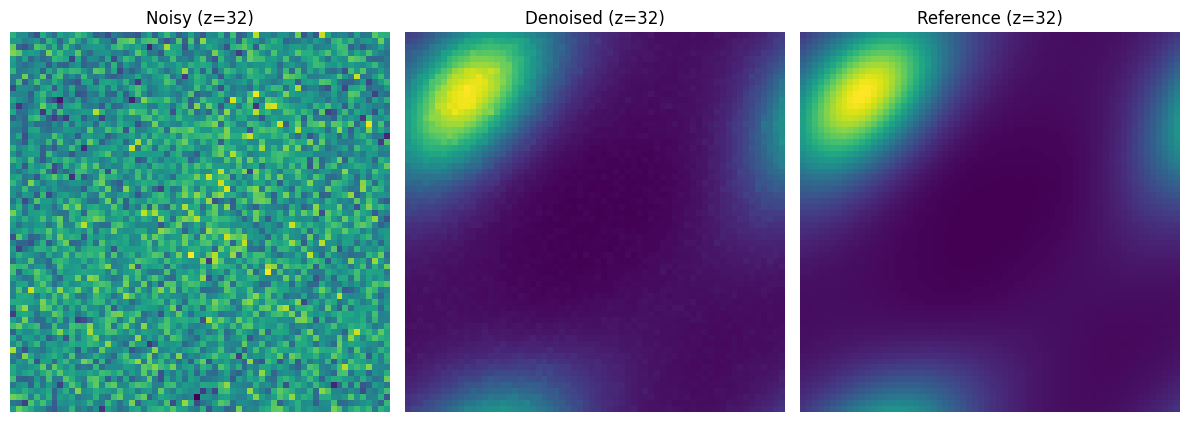


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0013762560_bm4d_denoised.npy
Sample 13762560 | bm4d JSD = 0.000196
20643840

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.1421
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000300
JSD   (denoised vs ref):  0.000146
(64, 64, 64) (64, 64, 64) (64, 64, 64)


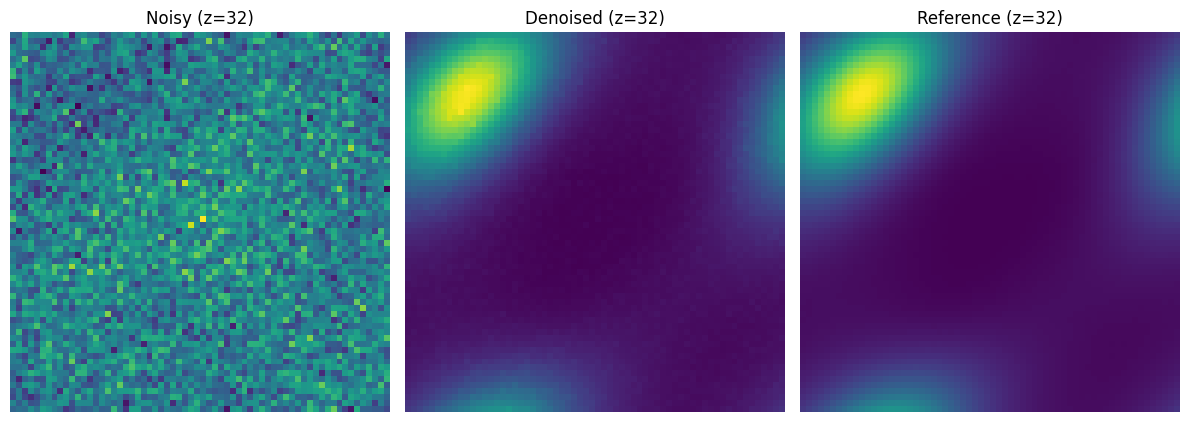


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0020643840_bm4d_denoised.npy
Sample 20643840 | bm4d JSD = 0.000146
27525120

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.1298
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000226
JSD   (denoised vs ref):  0.000122
(64, 64, 64) (64, 64, 64) (64, 64, 64)


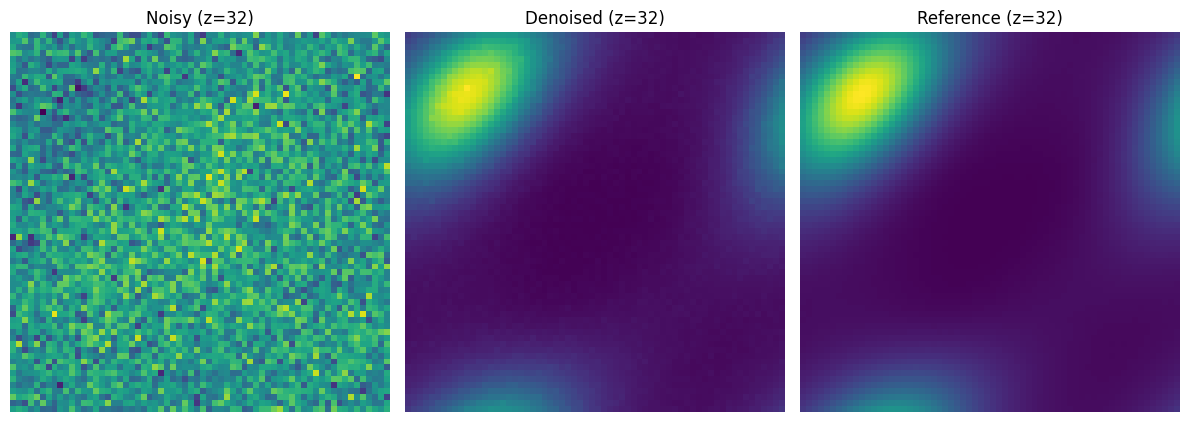


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0027525120_bm4d_denoised.npy
Sample 27525120 | bm4d JSD = 0.000122
41287680

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.1159
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000151
JSD   (denoised vs ref):  0.000097
(64, 64, 64) (64, 64, 64) (64, 64, 64)


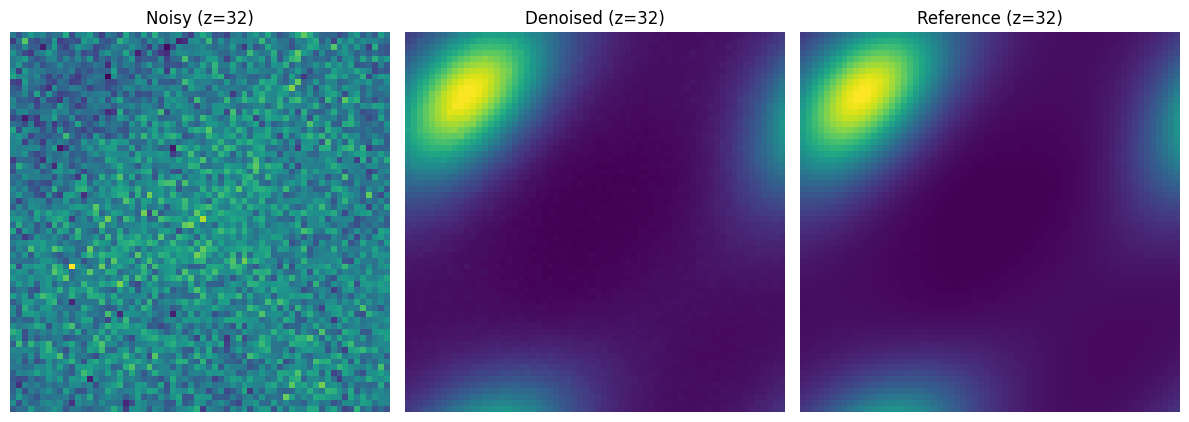


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0041287680_bm4d_denoised.npy
Sample 41287680 | bm4d JSD = 0.000097
55050240

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.1086
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000114
JSD   (denoised vs ref):  0.000084
(64, 64, 64) (64, 64, 64) (64, 64, 64)


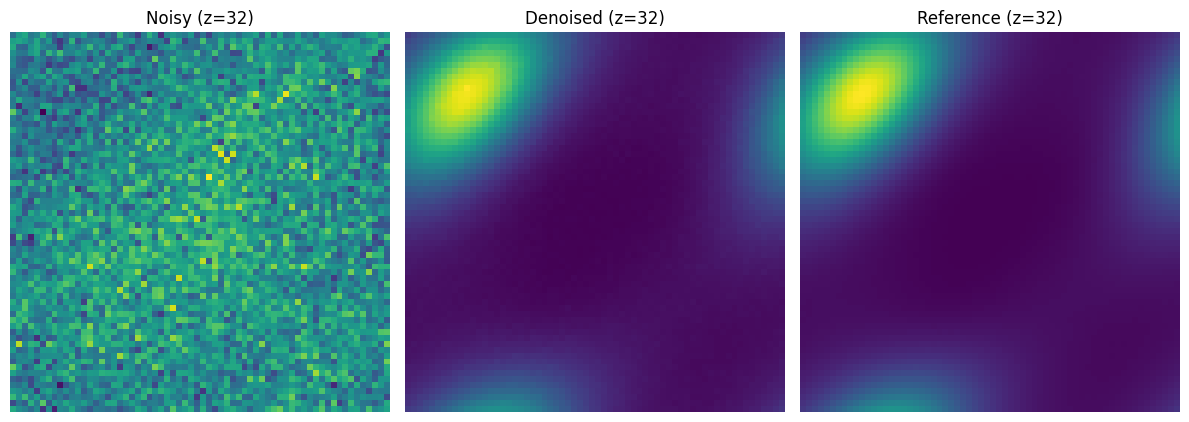


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0055050240_bm4d_denoised.npy
Sample 55050240 | bm4d JSD = 0.000084
82575360

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.1004
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000076
JSD   (denoised vs ref):  0.000070
(64, 64, 64) (64, 64, 64) (64, 64, 64)


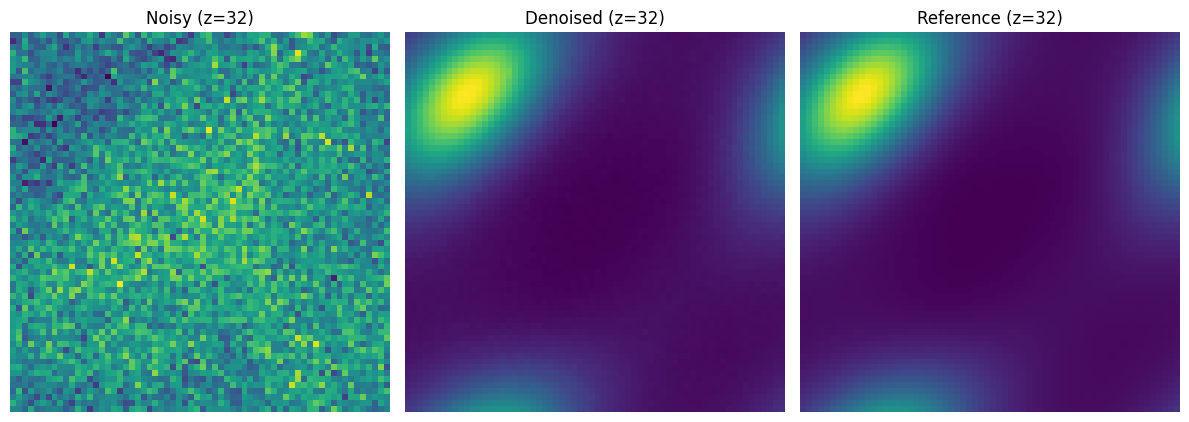


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0082575360_bm4d_denoised.npy
Sample 82575360 | bm4d JSD = 0.000070
110100480

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0961
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000057
JSD   (denoised vs ref):  0.000063
(64, 64, 64) (64, 64, 64) (64, 64, 64)


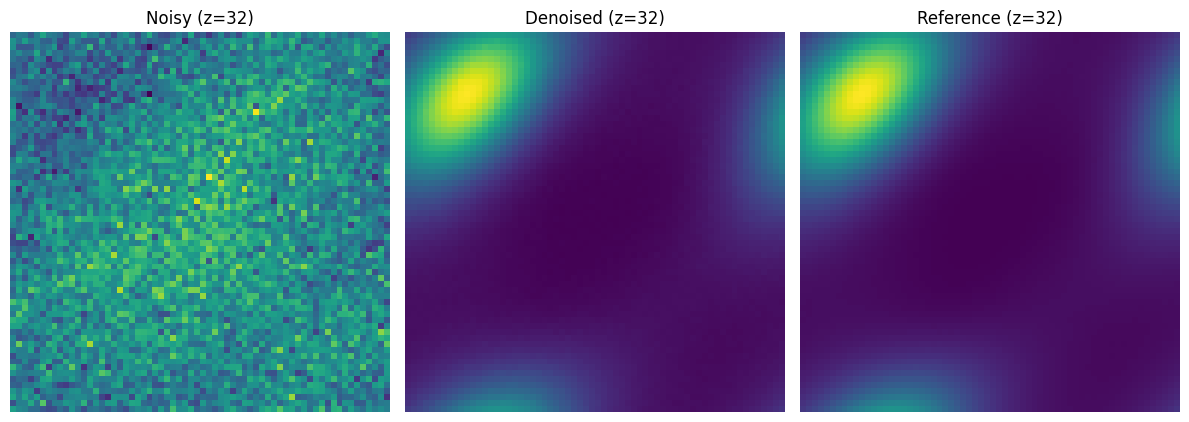


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0110100480_bm4d_denoised.npy
Sample 110100480 | bm4d JSD = 0.000063
165150720

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0914
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000039
JSD   (denoised vs ref):  0.000055
(64, 64, 64) (64, 64, 64) (64, 64, 64)


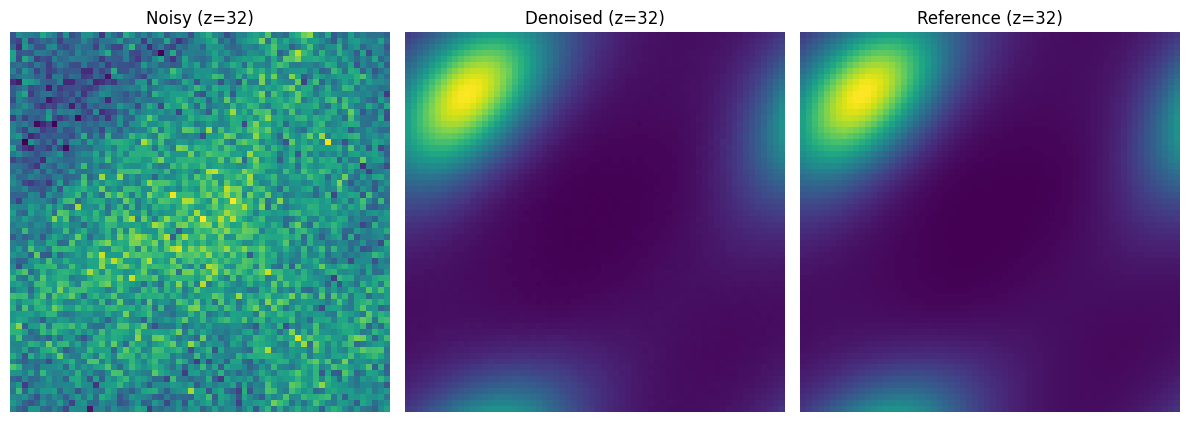


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0165150720_bm4d_denoised.npy
Sample 165150720 | bm4d JSD = 0.000055
220200960

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0891
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000029
JSD   (denoised vs ref):  0.000051
(64, 64, 64) (64, 64, 64) (64, 64, 64)


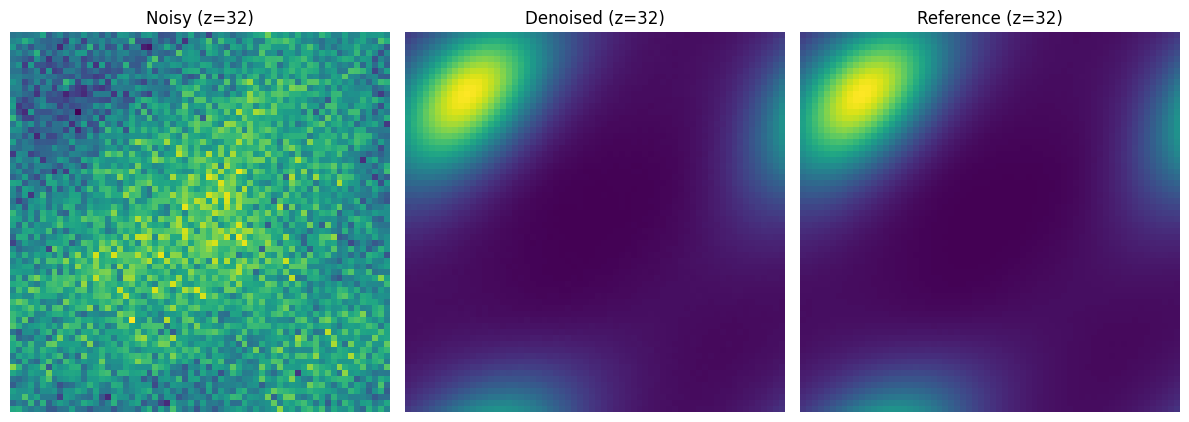


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0220200960_bm4d_denoised.npy
Sample 220200960 | bm4d JSD = 0.000051
330301440

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0867
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000020
JSD   (denoised vs ref):  0.000047
(64, 64, 64) (64, 64, 64) (64, 64, 64)


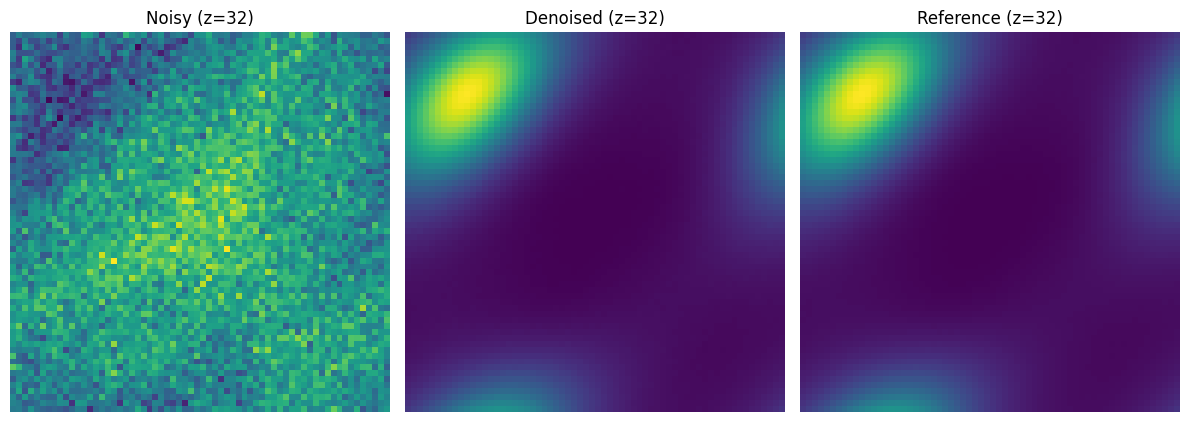


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0330301440_bm4d_denoised.npy
Sample 330301440 | bm4d JSD = 0.000047
440401920

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0855
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000015
JSD   (denoised vs ref):  0.000046
(64, 64, 64) (64, 64, 64) (64, 64, 64)


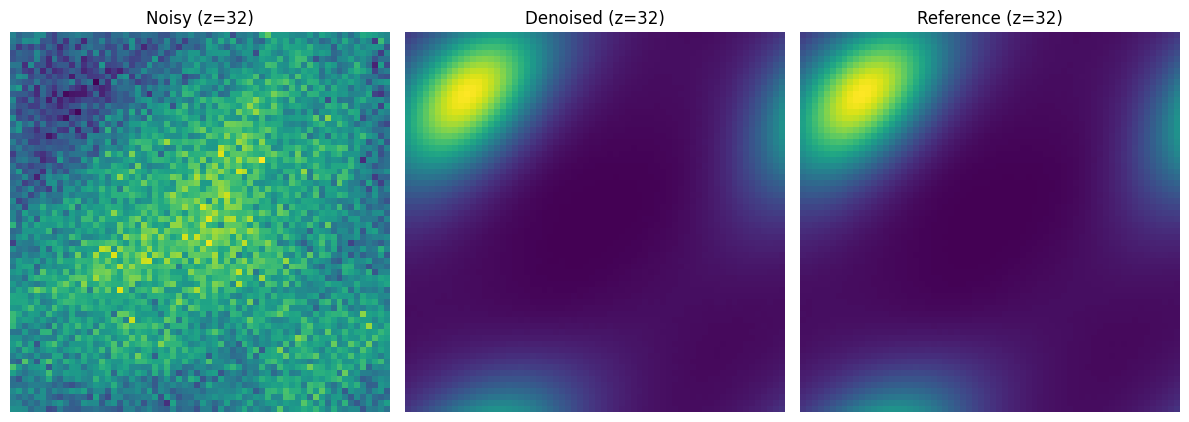


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0440401920_bm4d_denoised.npy
Sample 440401920 | bm4d JSD = 0.000046
660602880

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0843
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000010
JSD   (denoised vs ref):  0.000044
(64, 64, 64) (64, 64, 64) (64, 64, 64)


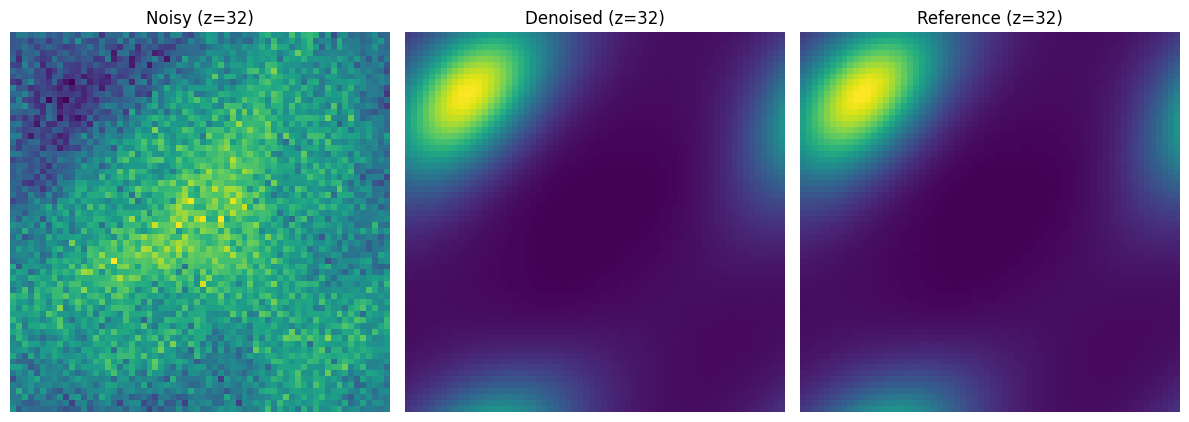


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0660602880_bm4d_denoised.npy
Sample 660602880 | bm4d JSD = 0.000044
1321205760

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0830
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000006
JSD   (denoised vs ref):  0.000043
(64, 64, 64) (64, 64, 64) (64, 64, 64)


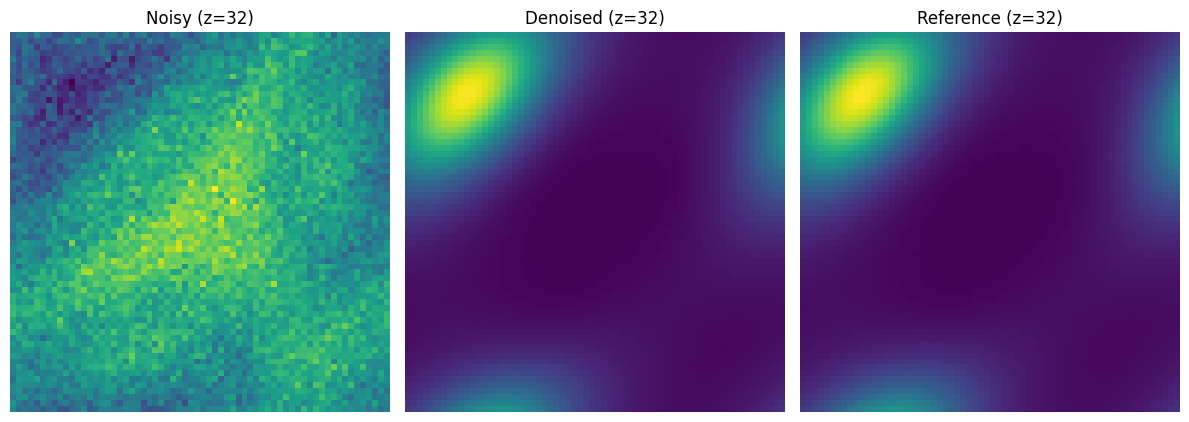


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_1321205760_bm4d_denoised.npy
Sample 1321205760 | bm4d JSD = 0.000043
2642411520

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0824
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000004
JSD   (denoised vs ref):  0.000043
(64, 64, 64) (64, 64, 64) (64, 64, 64)


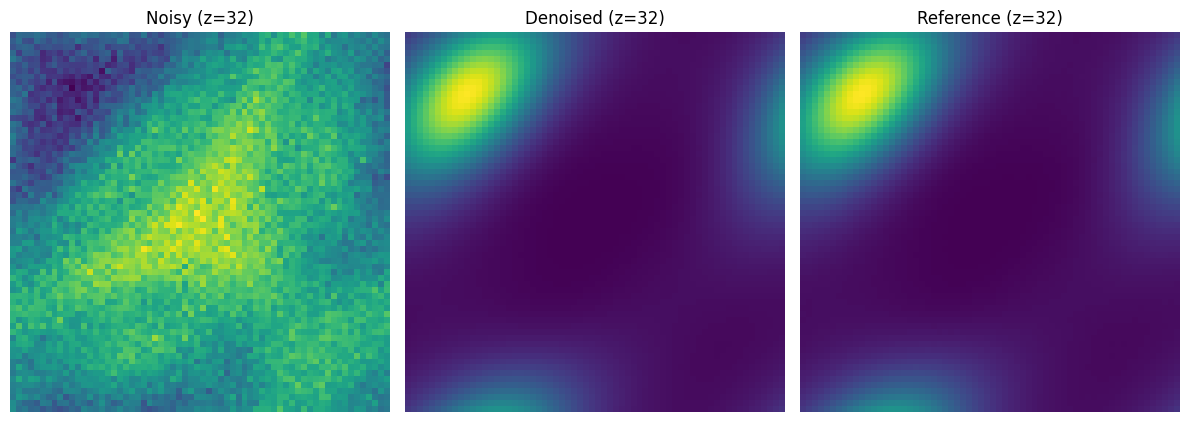


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_2642411520_bm4d_denoised.npy
Sample 2642411520 | bm4d JSD = 0.000043
5284823040

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0820
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000043
(64, 64, 64) (64, 64, 64) (64, 64, 64)


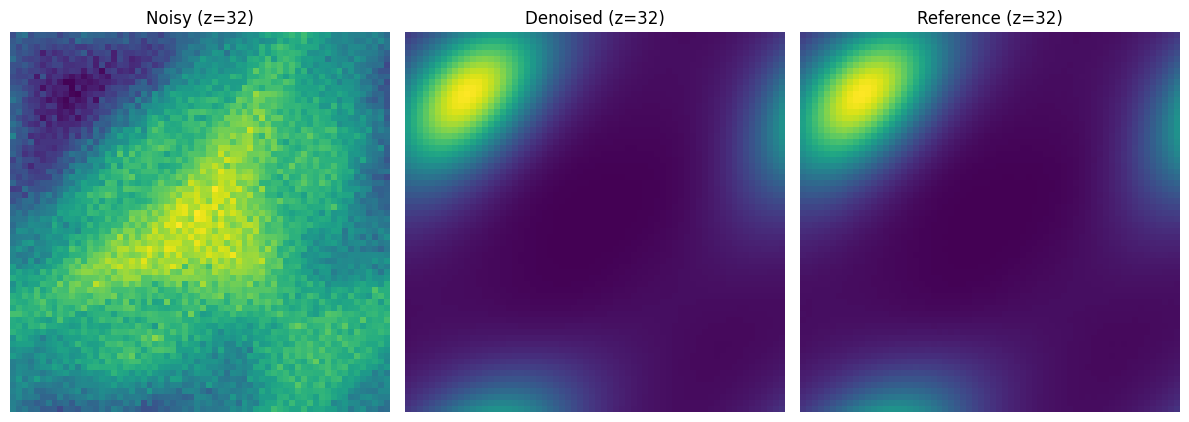


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_5284823040_bm4d_denoised.npy
Sample 5284823040 | bm4d JSD = 0.000043

=== Running model: bm3d ===
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     5.2365
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     52.063201
JSD   (denoised vs ref):  0.000120

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     5.2365
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     52.063201
JSD   (denoised vs ref):  0.000120


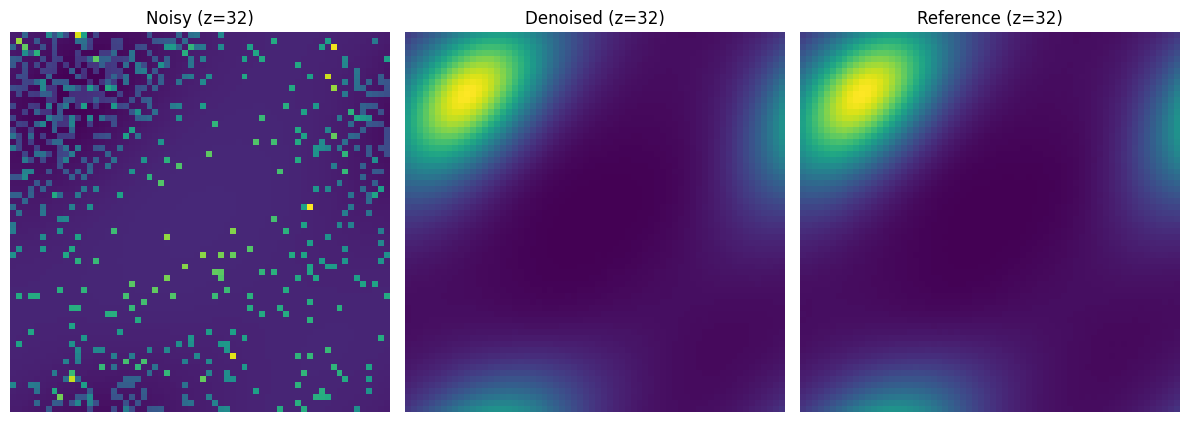


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000010240_bm3d_denoised.npy
Sample 10240 | bm3d JSD = 0.000120
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     3.7153
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     38.646104
JSD   (denoised vs ref):  0.000117

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     3.7153
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     38.646104
JSD   (denoised vs ref):  0.000117


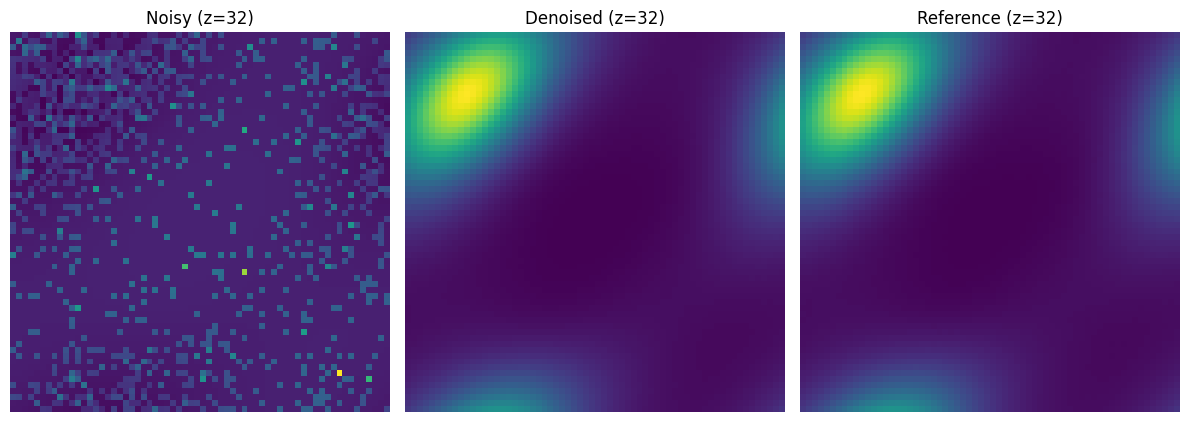


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000020480_bm3d_denoised.npy
Sample 20480 | bm3d JSD = 0.000117
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     2.6176
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     34.109040
JSD   (denoised vs ref):  0.000114

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     2.6176
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     34.109040
JSD   (denoised vs ref):  0.000114


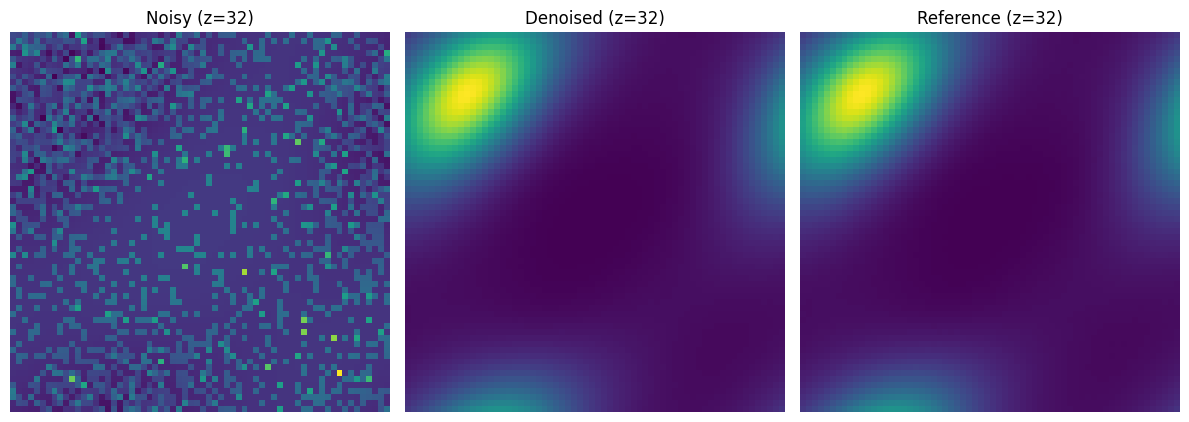


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000040960_bm3d_denoised.npy
Sample 40960 | bm3d JSD = 0.000114
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     1.8514
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     24.002402
JSD   (denoised vs ref):  0.000111

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     1.8514
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     24.002402
JSD   (denoised vs ref):  0.000111


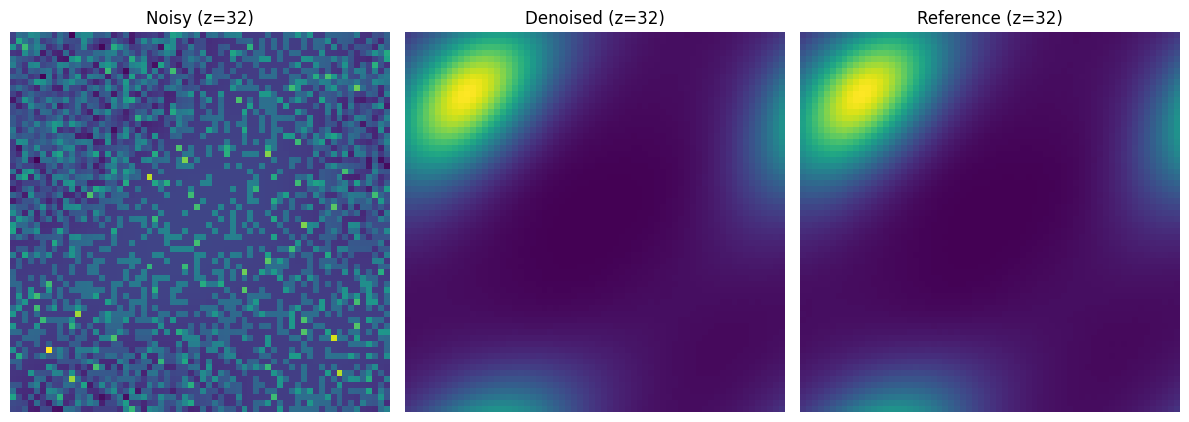


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000081920_bm3d_denoised.npy
Sample 81920 | bm3d JSD = 0.000111
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     1.3096
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     19.183826
JSD   (denoised vs ref):  0.000108

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     1.3096
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     19.183826
JSD   (denoised vs ref):  0.000108


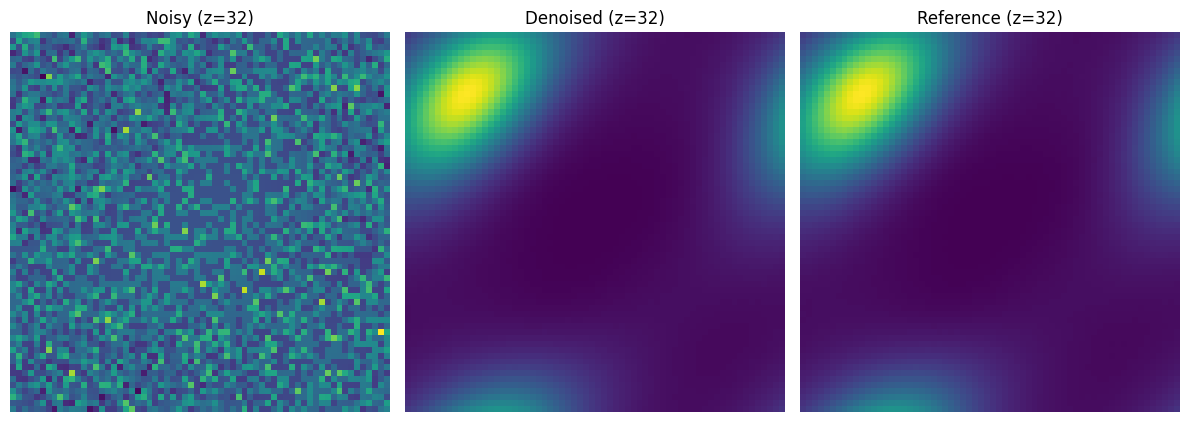


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000163840_bm3d_denoised.npy
Sample 163840 | bm3d JSD = 0.000108
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.9276
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     13.825756
JSD   (denoised vs ref):  0.000106

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.9276
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     13.825756
JSD   (denoised vs ref):  0.000106


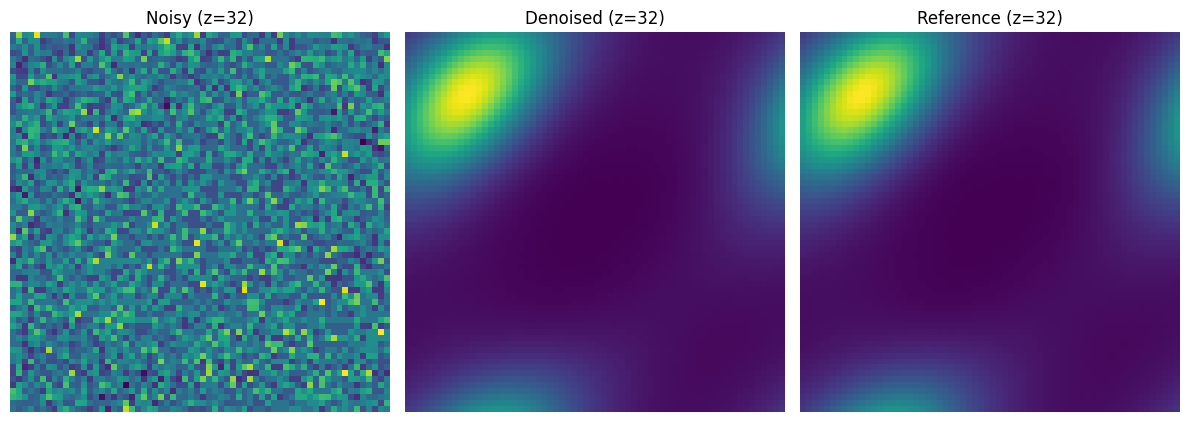


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000327680_bm3d_denoised.npy
Sample 327680 | bm3d JSD = 0.000106
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.8108
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     11.998552
JSD   (denoised vs ref):  0.000105

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.8108
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     11.998552
JSD   (denoised vs ref):  0.000105


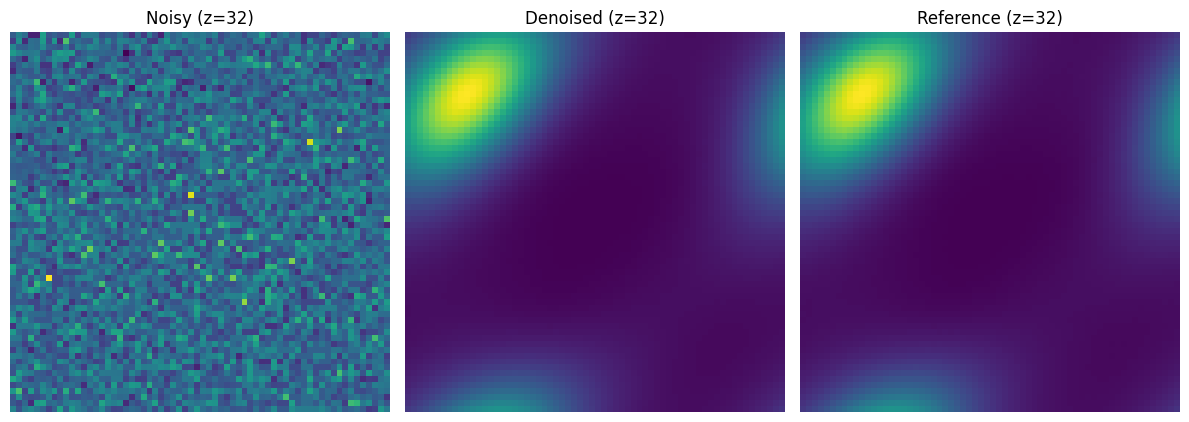


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000430080_bm3d_denoised.npy
Sample 430080 | bm3d JSD = 0.000105
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.6583
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     9.441314
JSD   (denoised vs ref):  0.000104

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.6583
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     9.441314
JSD   (denoised vs ref):  0.000104


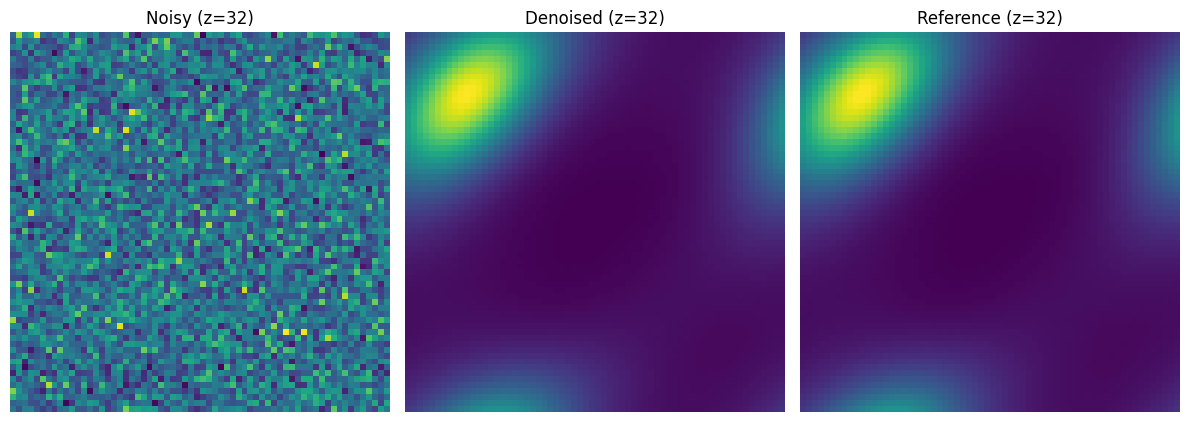


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000655360_bm3d_denoised.npy
Sample 655360 | bm3d JSD = 0.000104
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.5753
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     8.264836
JSD   (denoised vs ref):  0.000103

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.5753
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     8.264836
JSD   (denoised vs ref):  0.000103


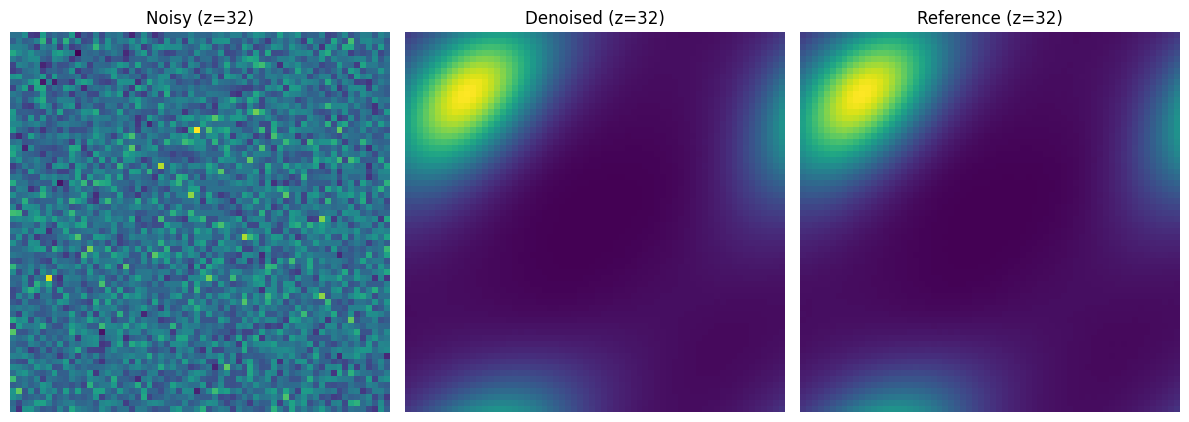


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000860160_bm3d_denoised.npy
Sample 860160 | bm3d JSD = 0.000103
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.4693
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     6.710627
JSD   (denoised vs ref):  0.000102

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.4693
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     6.710627
JSD   (denoised vs ref):  0.000102


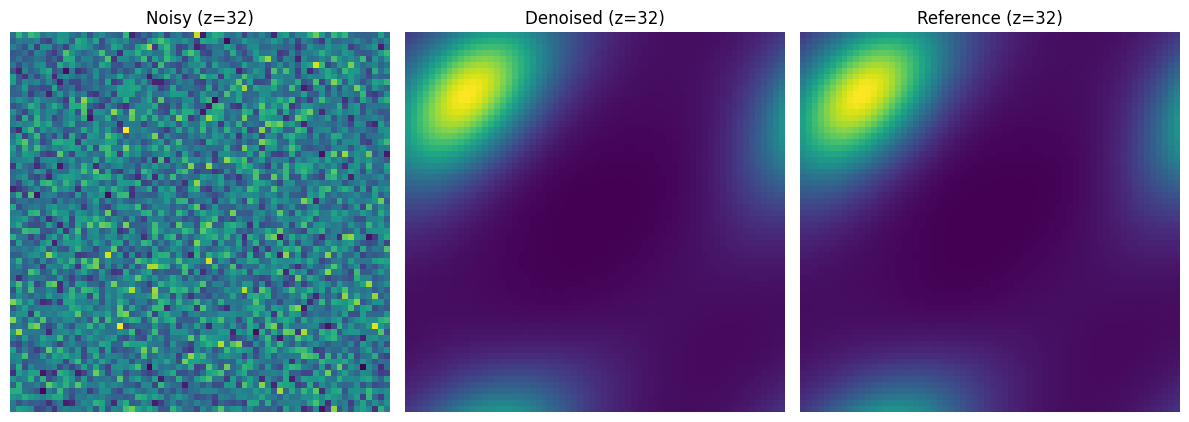


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0001310720_bm3d_denoised.npy
Sample 1310720 | bm3d JSD = 0.000102
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.4100
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     5.773285
JSD   (denoised vs ref):  0.000102

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.4100
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     5.773285
JSD   (denoised vs ref):  0.000102


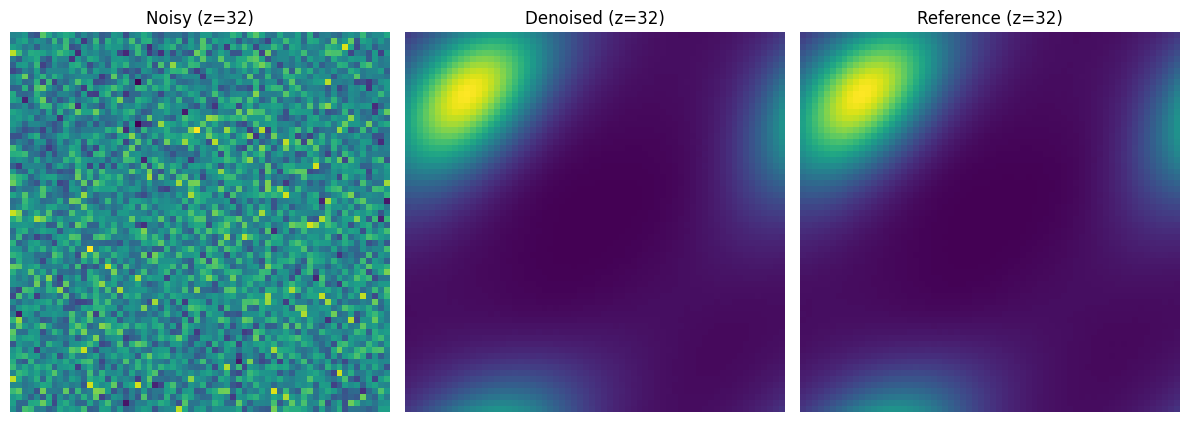


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0001720320_bm3d_denoised.npy
Sample 1720320 | bm3d JSD = 0.000102
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.3366
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     4.829274
JSD   (denoised vs ref):  0.000101

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.3366
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     4.829274
JSD   (denoised vs ref):  0.000101


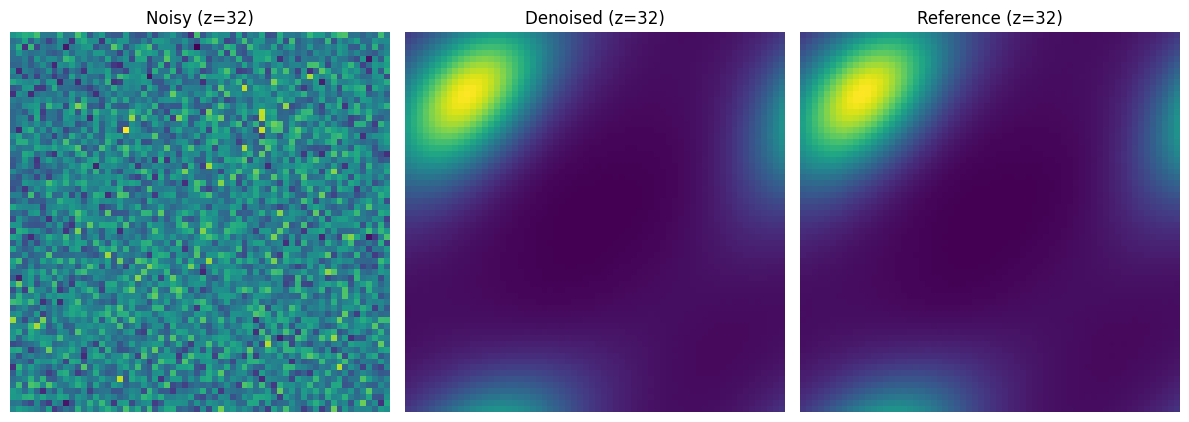


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0002621440_bm3d_denoised.npy
Sample 2621440 | bm3d JSD = 0.000101
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.2957
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     4.214717
JSD   (denoised vs ref):  0.000100

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.2957
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     4.214717
JSD   (denoised vs ref):  0.000100


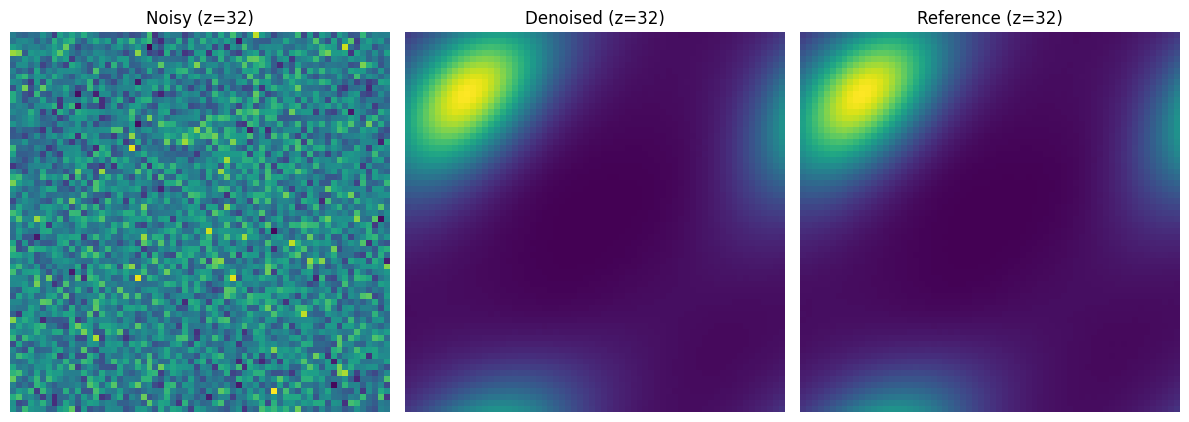


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0003440640_bm3d_denoised.npy
Sample 3440640 | bm3d JSD = 0.000100
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.2466
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     3.612919
JSD   (denoised vs ref):  0.000099

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.2466
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     3.612919
JSD   (denoised vs ref):  0.000099


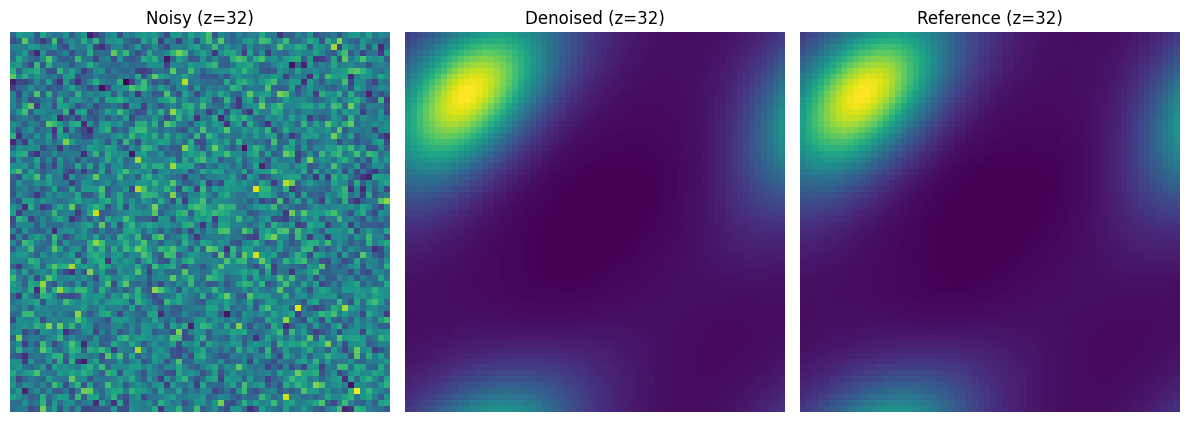


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0005160960_bm3d_denoised.npy
Sample 5160960 | bm3d JSD = 0.000099
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.2450
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     3.572269
JSD   (denoised vs ref):  0.000098

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.2450
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     3.572269
JSD   (denoised vs ref):  0.000098


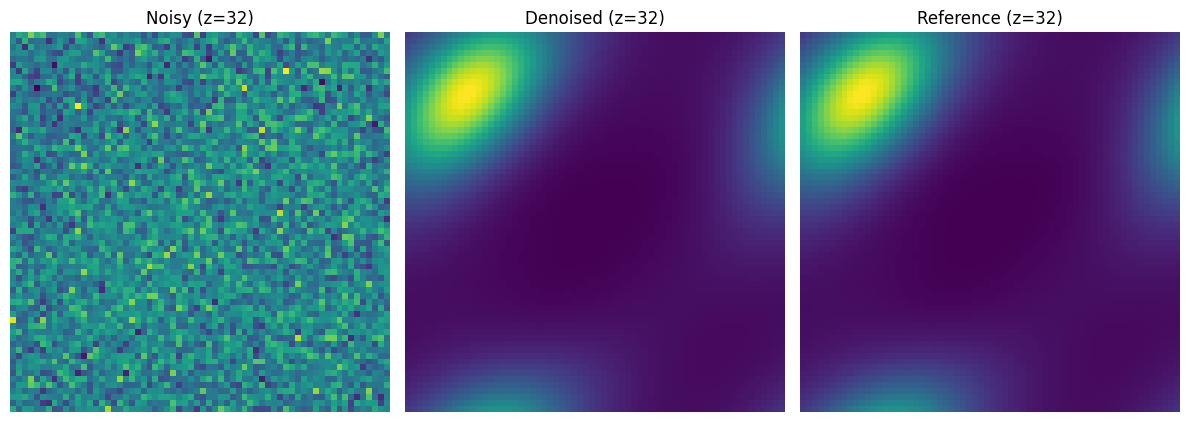


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0005242880_bm3d_denoised.npy
Sample 5242880 | bm3d JSD = 0.000098
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.2177
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     3.210400
JSD   (denoised vs ref):  0.000097

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.2177
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     3.210400
JSD   (denoised vs ref):  0.000097


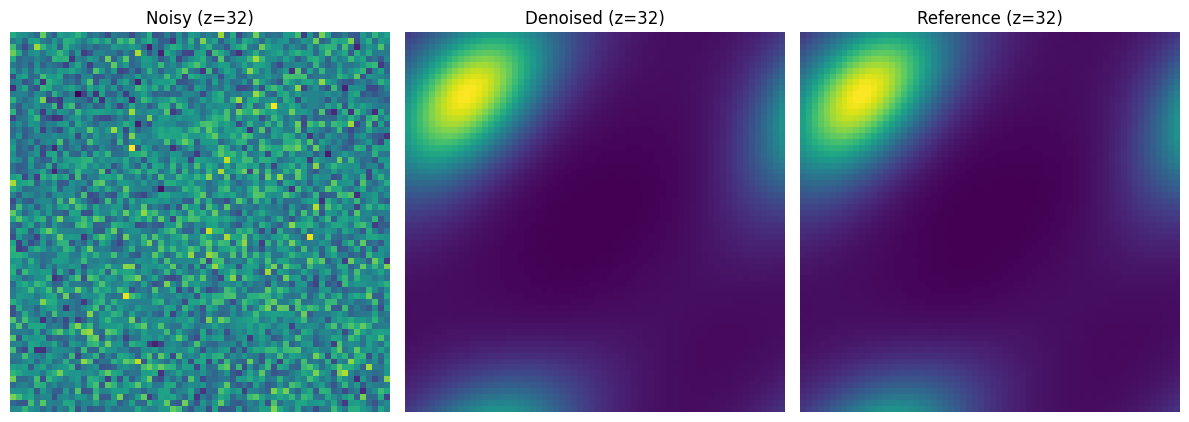


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0006881280_bm3d_denoised.npy
Sample 6881280 | bm3d JSD = 0.000097
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.1835
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     2.825540
JSD   (denoised vs ref):  0.000096

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.1835
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     2.825540
JSD   (denoised vs ref):  0.000096


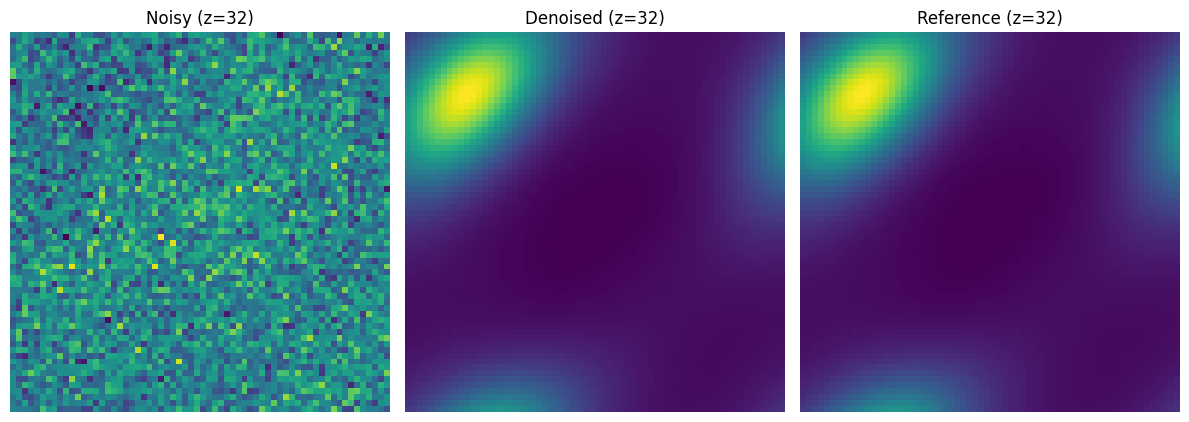


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0010321920_bm3d_denoised.npy
Sample 10321920 | bm3d JSD = 0.000096
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.1826
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     2.823653
JSD   (denoised vs ref):  0.000096

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.1826
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     2.823653
JSD   (denoised vs ref):  0.000096


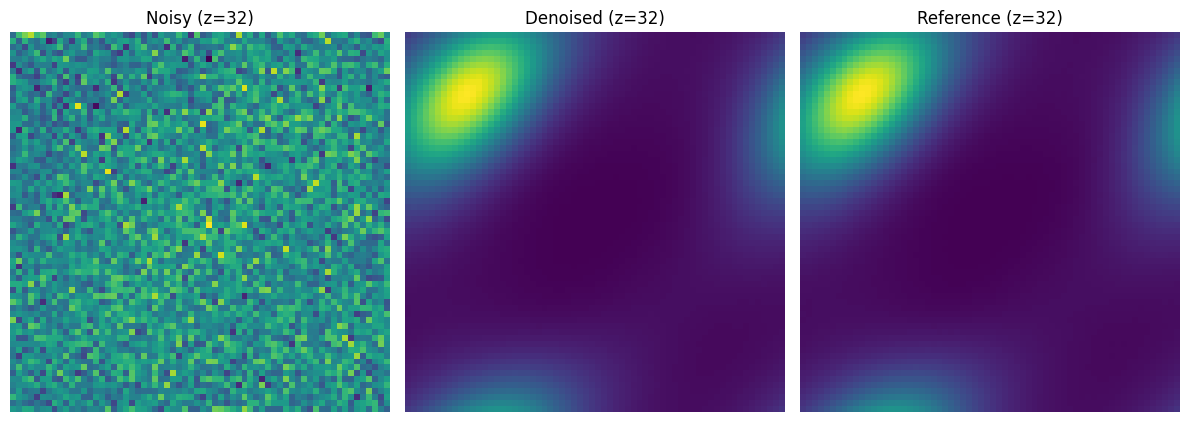


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0010485760_bm3d_denoised.npy
Sample 10485760 | bm3d JSD = 0.000096
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.1643
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     2.590050
JSD   (denoised vs ref):  0.000095

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.1643
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     2.590050
JSD   (denoised vs ref):  0.000095


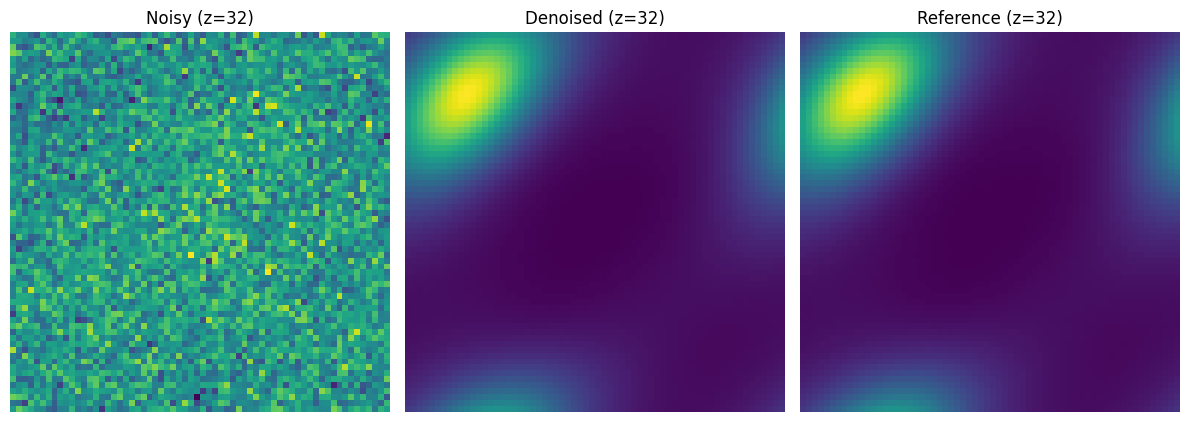


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0013762560_bm3d_denoised.npy
Sample 13762560 | bm3d JSD = 0.000095
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.1421
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     2.342830
JSD   (denoised vs ref):  0.000094

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.1421
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     2.342830
JSD   (denoised vs ref):  0.000094


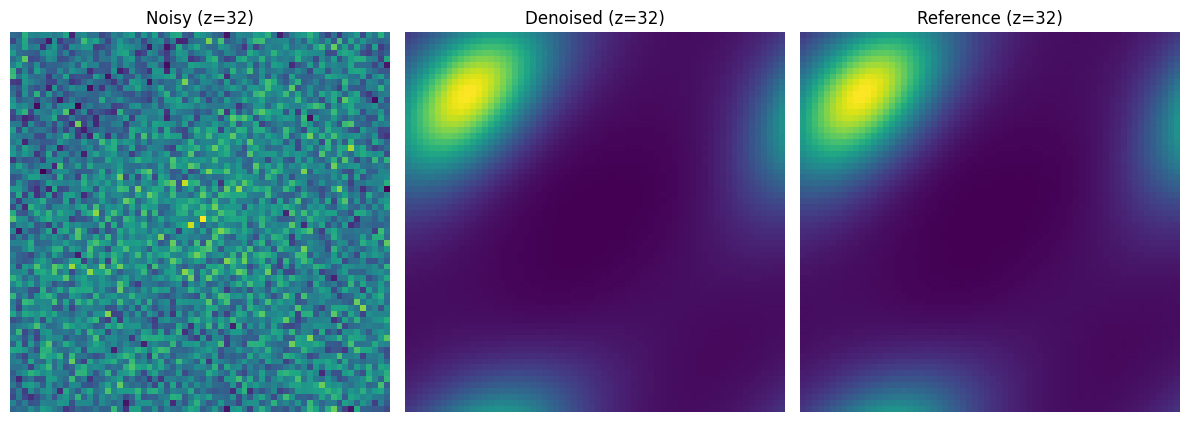


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0020643840_bm3d_denoised.npy
Sample 20643840 | bm3d JSD = 0.000094
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.1298
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     2.207554
JSD   (denoised vs ref):  0.000092

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.1298
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     2.207554
JSD   (denoised vs ref):  0.000092


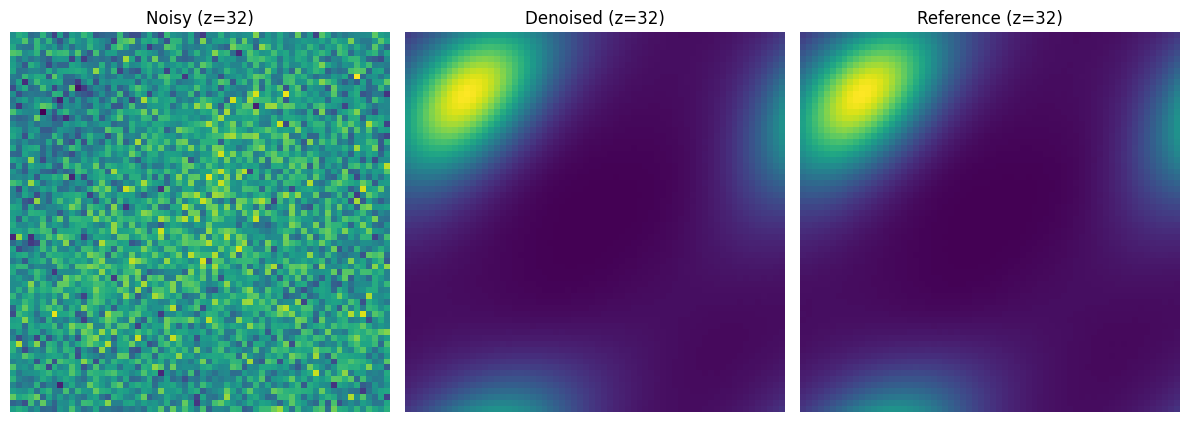


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0027525120_bm3d_denoised.npy
Sample 27525120 | bm3d JSD = 0.000092
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.1159
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     2.052071
JSD   (denoised vs ref):  0.000091

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.1159
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     2.052071
JSD   (denoised vs ref):  0.000091


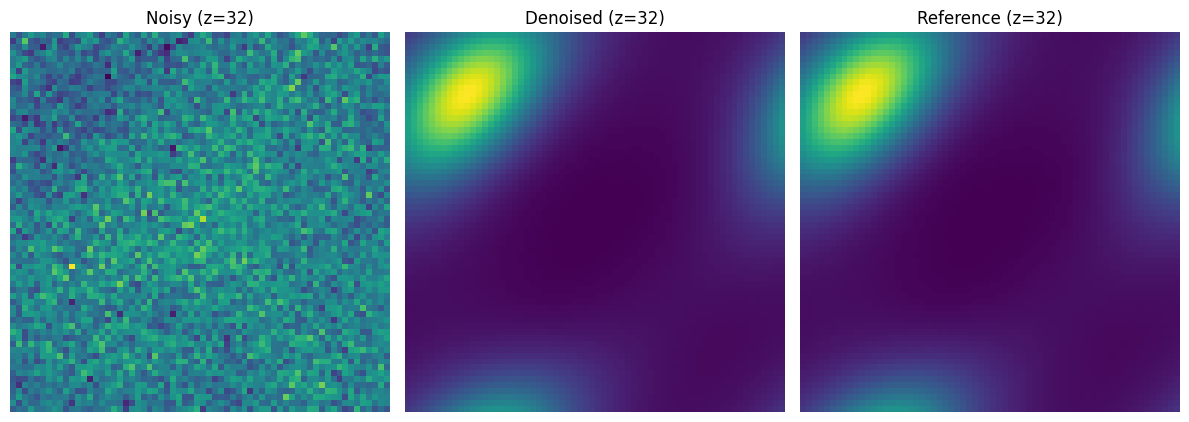


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0041287680_bm3d_denoised.npy
Sample 41287680 | bm3d JSD = 0.000091
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.1086
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     1.961343
JSD   (denoised vs ref):  0.000090

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.1086
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     1.961343
JSD   (denoised vs ref):  0.000090


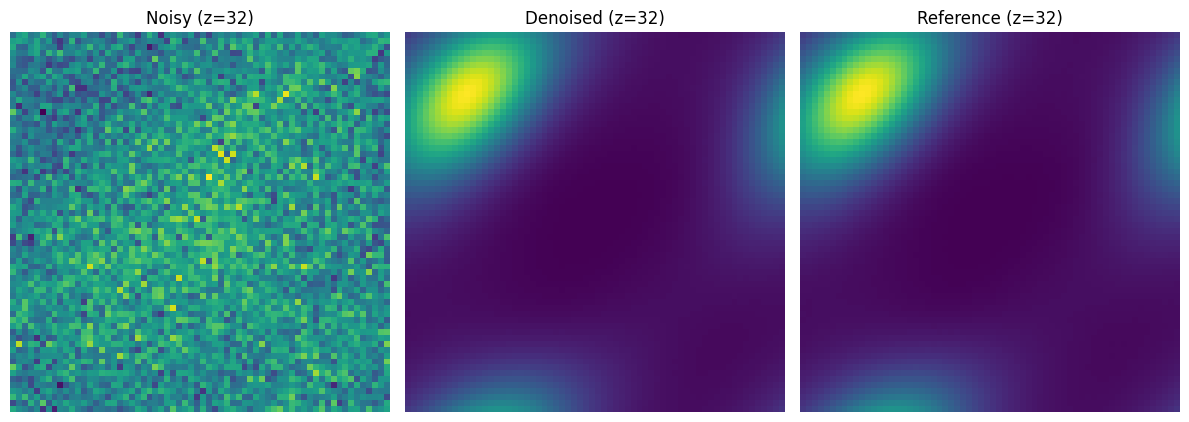


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0055050240_bm3d_denoised.npy
Sample 55050240 | bm3d JSD = 0.000090
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.1004
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     1.854723
JSD   (denoised vs ref):  0.000088

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.1004
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     1.854723
JSD   (denoised vs ref):  0.000088


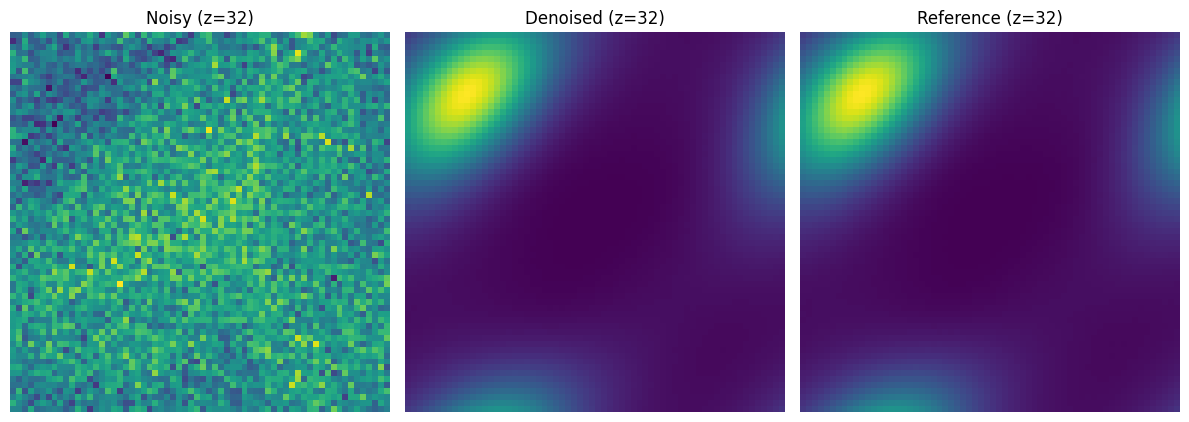


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0082575360_bm3d_denoised.npy
Sample 82575360 | bm3d JSD = 0.000088
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0961
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     1.797909
JSD   (denoised vs ref):  0.000087

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0961
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     1.797909
JSD   (denoised vs ref):  0.000087


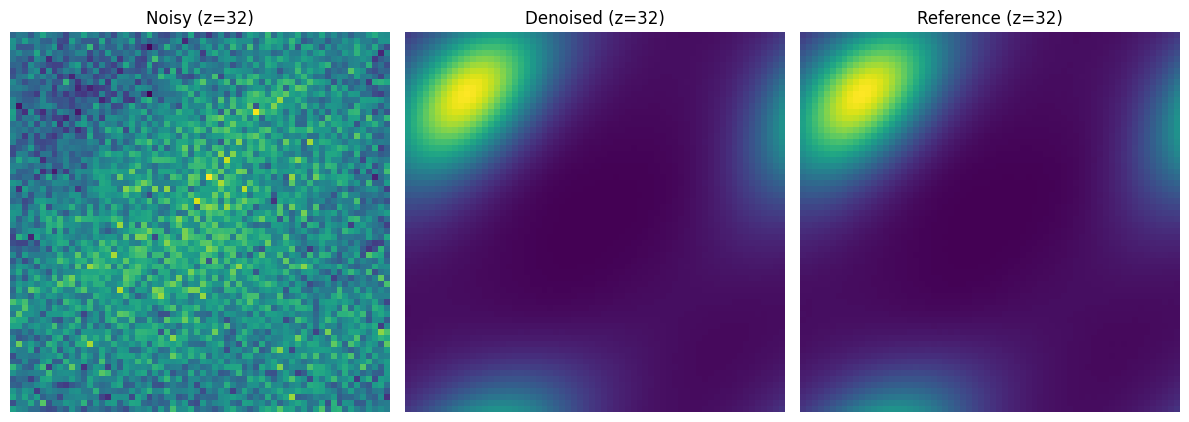


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0110100480_bm3d_denoised.npy
Sample 110100480 | bm3d JSD = 0.000087
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0914
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     1.720404
JSD   (denoised vs ref):  0.000085

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0914
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     1.720404
JSD   (denoised vs ref):  0.000085


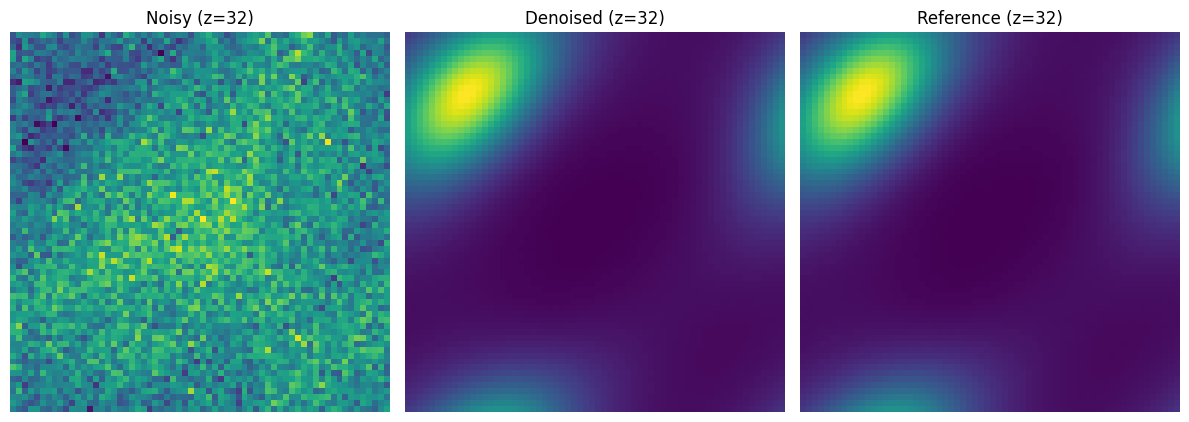


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0165150720_bm3d_denoised.npy
Sample 165150720 | bm3d JSD = 0.000085
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0891
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     1.684438
JSD   (denoised vs ref):  0.000084

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0891
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     1.684438
JSD   (denoised vs ref):  0.000084


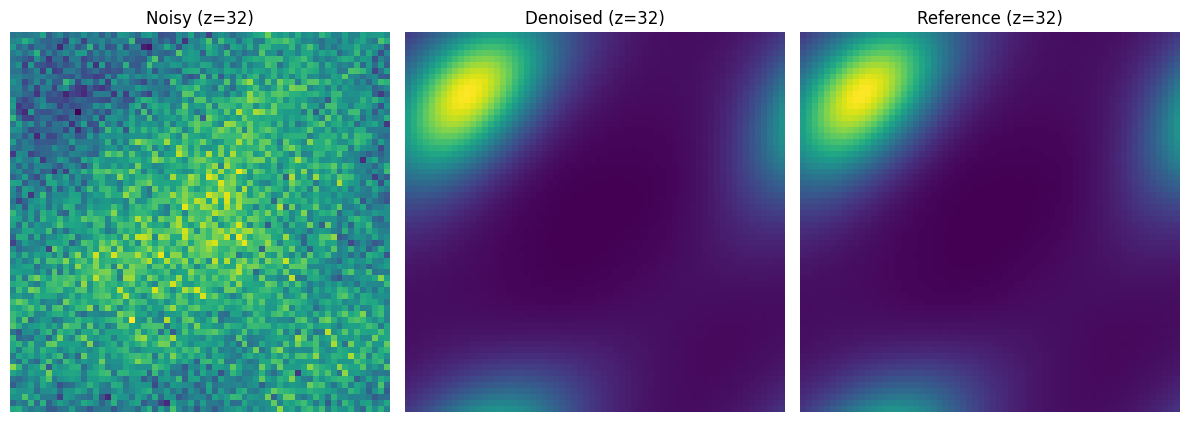


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0220200960_bm3d_denoised.npy
Sample 220200960 | bm3d JSD = 0.000084
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0867
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     1.640221
JSD   (denoised vs ref):  0.000082

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0867
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     1.640221
JSD   (denoised vs ref):  0.000082


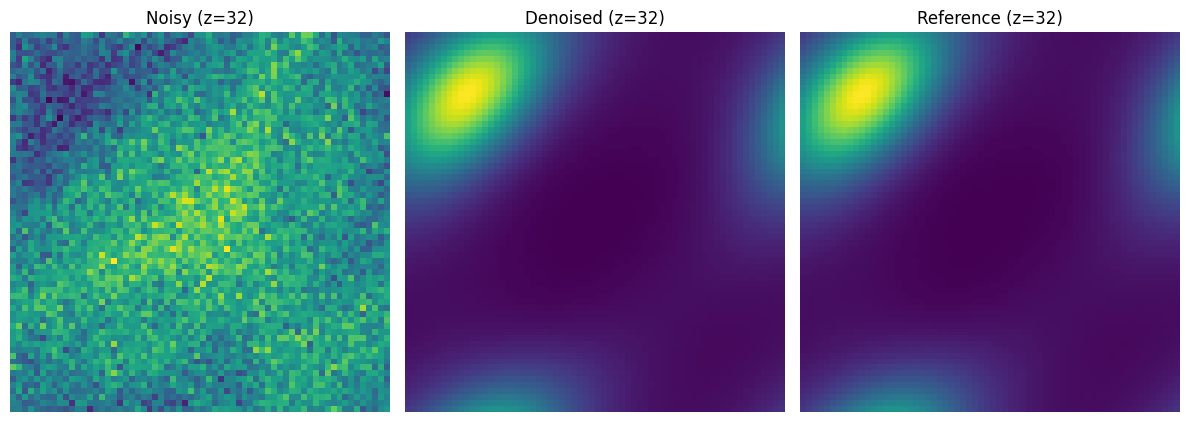


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0330301440_bm3d_denoised.npy
Sample 330301440 | bm3d JSD = 0.000082
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0855
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     1.616228
JSD   (denoised vs ref):  0.000081

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0855
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     1.616228
JSD   (denoised vs ref):  0.000081


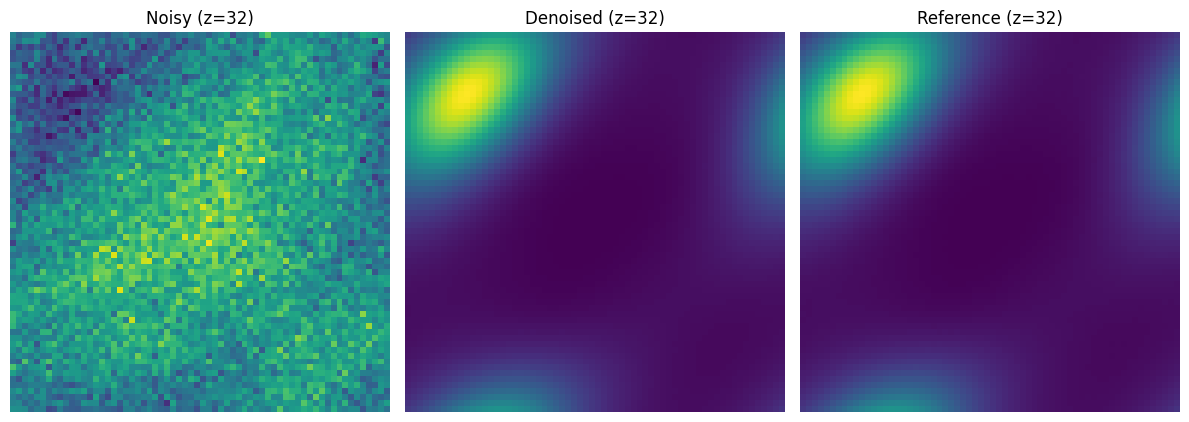


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0440401920_bm3d_denoised.npy
Sample 440401920 | bm3d JSD = 0.000081
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0843
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     1.591536
JSD   (denoised vs ref):  0.000080

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0843
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     1.591536
JSD   (denoised vs ref):  0.000080


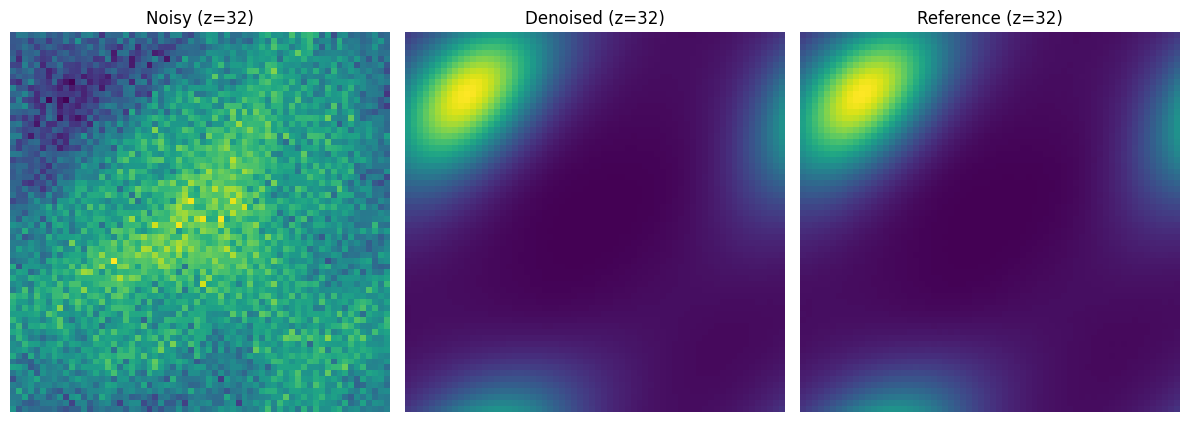


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0660602880_bm3d_denoised.npy
Sample 660602880 | bm3d JSD = 0.000080
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0830
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     1.564715
JSD   (denoised vs ref):  0.000078

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0830
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     1.564715
JSD   (denoised vs ref):  0.000078


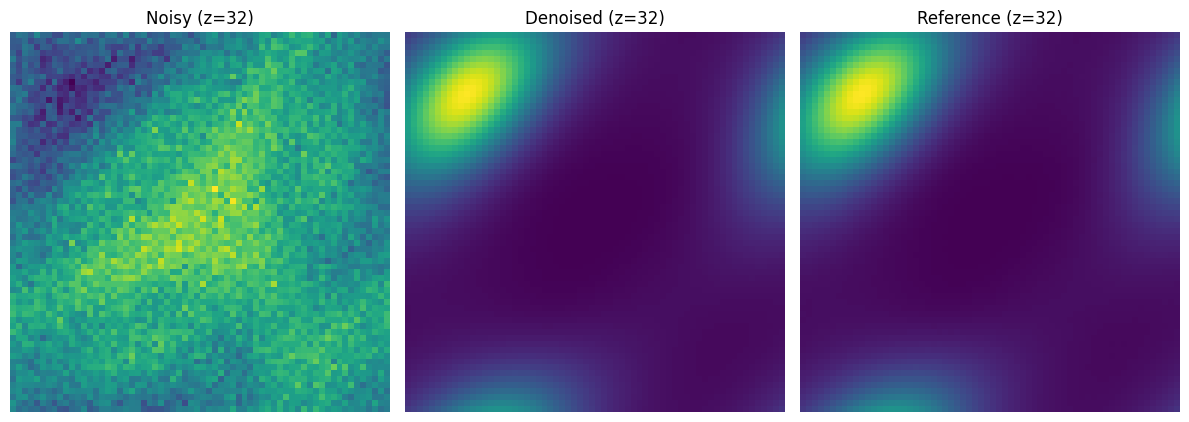


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_1321205760_bm3d_denoised.npy
Sample 1321205760 | bm3d JSD = 0.000078
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0824
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     1.554853
JSD   (denoised vs ref):  0.000077

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0824
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     1.554853
JSD   (denoised vs ref):  0.000077


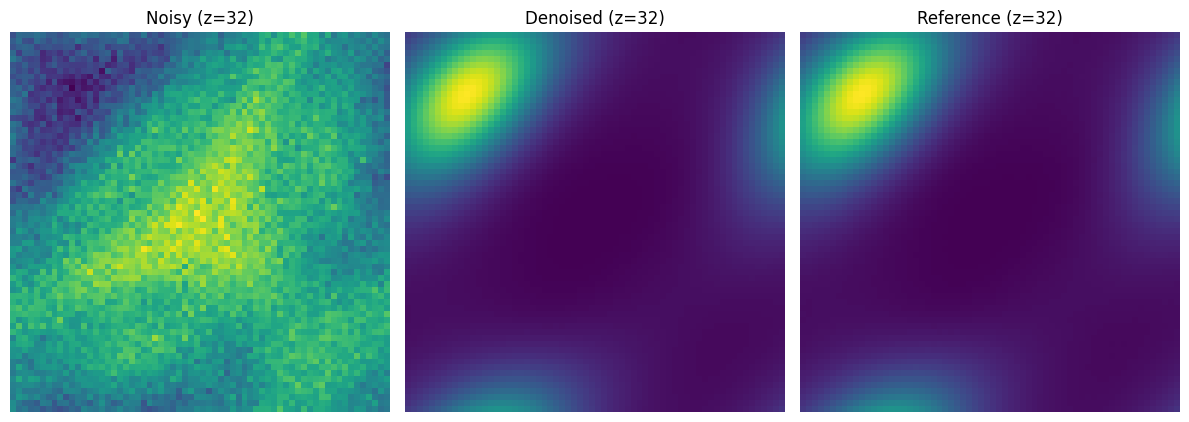


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_2642411520_bm3d_denoised.npy
Sample 2642411520 | bm3d JSD = 0.000077
here
(64, 64, 64, 3)

>>> Evaluation Metrics 2D
2-norm (noisy vs ref):     0.0820
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     1.549535
JSD   (denoised vs ref):  0.000076

>>> Evaluation Metrics 3D
2-norm (noisy vs ref):     0.0820
2-norm (denoised vs ref): 0.0005
JSD   (noisy vs ref):     1.549535
JSD   (denoised vs ref):  0.000076


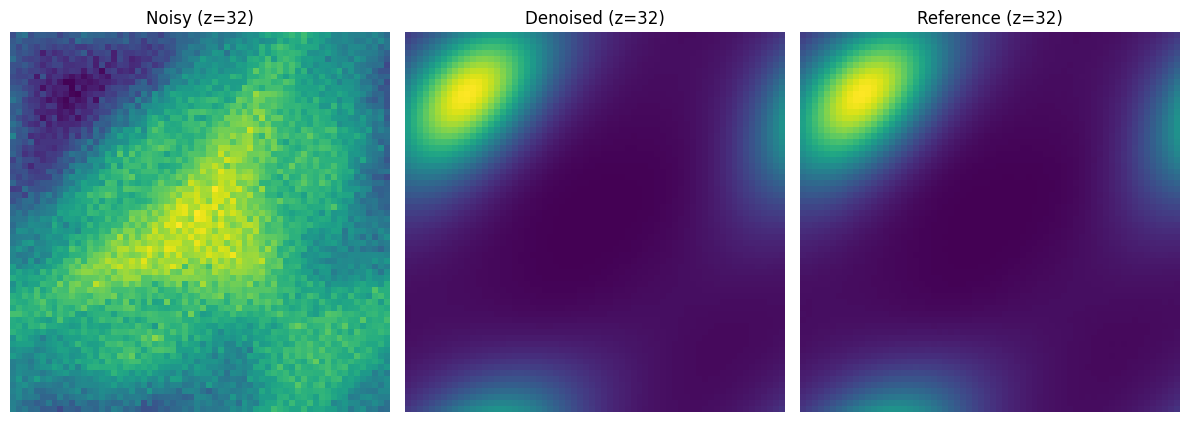


 Denoised matrix saved to /pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_5284823040_bm3d_denoised.npy
Sample 5284823040 | bm3d JSD = 0.000076


In [15]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
import h5py

# ================= CPU-loading patch =================
_original_torch_load = torch.load
def torch_load_cpu(*args, **kwargs):
    if 'map_location' not in kwargs:
        kwargs['map_location'] = torch.device('cpu')
    return _original_torch_load(*args, **kwargs)
torch.load = torch_load_cpu

# ================= Paths & Models =================
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")
noisy_files = sorted(glob.glob(os.path.join(base_dir, "density_tot_vmc_mean*.h5")))

models = [
    'bm4d','bm3d'
]

print(f"Found {len(noisy_files)} noisy files.")

# ================= Reference JSD =================
results_ref = []
for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))

    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]
    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]

    jsd = D_JS(ref_d, test_d)
    results_ref.append((sample_num, jsd))

results_array_ref = np.array(sorted(results_ref, key=lambda x: x[0]))

# ================= Run models =================
results_dict = {model: [] for model in models}

for model_name in models:
    print(f"\n=== Running model: {model_name} ===")

    for noisy_path in noisy_files:
        match = re.search(r"(\d+)\.h5$", noisy_path)
        if not match:
            continue
        sample_num = int(match.group(1))
        sample_count = sample_num

        output_file = os.path.splitext(os.path.basename(noisy_path))[0] + f"_{model_name}_denoised.npy"
        output_path = os.path.join(base_dir, output_file)

        denoised_den, jsd = run_denoising_pipeline(
            noisy_path,
            ref_path,
            model_name,
            output_file=output_path
        )

        results_dict[model_name].append((sample_num, jsd))
        print(f"Sample {sample_num} | {model_name} JSD = {jsd:.6f}")


In [16]:
import pandas as pd
df = pd.DataFrame(results_dict)
df.to_csv('BM3D_4D_jsd_results_Full.csv', index=False)

print("Dictionary saved to results.csv")

Dictionary saved to results.csv


In [17]:
# ==== Reference JSD ====
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")
results_ref = []
with h5py.File(ref_path, 'r') as file:
    ref_d_full = file['density'][:]

In [18]:
with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    dft_d = file['density'][:]
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_ref_mean.h5', 'r') as file:
    VMC_ref = file['density'][:]
DFT_vs_VMC = D_JS(VMC_ref, dft_d)
print(DFT_vs_VMC)   

0.00012671965457473964


In [19]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
import h5py


# ================= Paths & Models =================
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")

#print(ref_d)

noisy_files = sorted(glob.glob(os.path.join(base_dir, "density_tot_vmc_mean*.h5")))

print(f"Found {len(noisy_files)} noisy files.")





Found 33 noisy files.


In [20]:
import sys
import os
qmc_algo_path = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/qmc_algo_tools') 
dev = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/developer_tools') 

sys.path.insert(0, qmc_algo_path) 
sys.path.insert(0, dev) 

#! /usr/bin/env python3

#from qmc_algo_tools.density_data import DensityData
from qmc_algo_tools.density_denoise import DensityFourierFilterErrorCeil
#from qmc_algo_tools.density_denoise import D_JS


def div_js_dens(d1,d2):
    return D_JS(d1,d2)

model_results_FFT = []
for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))

    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]
    dm = DensityFourierFilterErrorCeil(density_ref= ref_d_full,filter_mode='augment')

    d_denoised = dm.denoise(test_d)
    jsd_denoised = D_JS(d_denoised, VMC_ref)
    model_results_FFT.append((sample_num, jsd_denoised))
    
print(model_results_FFT)

[(10240, np.float64(0.0004958021516458999)), (20480, np.float64(0.00035785791120515126)), (40960, np.float64(0.00034091570417411486)), (81920, np.float64(0.00016652200556377863)), (163840, np.float64(0.00016514577009432493)), (327680, np.float64(0.00012410201778579536)), (430080, np.float64(0.00011393499717519147)), (655360, np.float64(5.704556673483544e-05)), (860160, np.float64(3.832958980866265e-05)), (1310720, np.float64(3.73399720451121e-05)), (1720320, np.float64(2.9594738827180698e-05)), (2621440, np.float64(2.164391797361874e-05)), (3440640, np.float64(1.994740403861775e-05)), (5160960, np.float64(1.46032036374252e-05)), (5242880, np.float64(1.4118056596091955e-05)), (6881280, np.float64(9.81757400710268e-06)), (10321920, np.float64(7.711870693292213e-06)), (10485760, np.float64(7.051194486897614e-06)), (13762560, np.float64(5.244409777187951e-06)), (20643840, np.float64(4.551259923227013e-06)), (27525120, np.float64(3.3201592676747415e-06)), (41287680, np.float64(2.44839415275

In [21]:
import sys
import os
import h5py
qmc_algo_path = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/qmc_algo_tools') 
dev = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/developer_tools') 

sys.path.insert(0, qmc_algo_path) 
sys.path.insert(0, dev) 

ref_path = '/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5' #DFT
with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    ref_d = file['density'][:]

#! /usr/bin/env python3

#from qmc_algo_tools.density_data import DensityData
from qmc_algo_tools.density_denoise import DensityFourierFilterErrorCeil
#from qmc_algo_tools.density_denoise import D_JS


model_results_FFT = []
for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))
    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]

    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]
    dm = DensityFourierFilterErrorCeil(density_ref= ref_d,filter_mode='augment')

    d_denoised = dm.denoise(test_d)
    jsd_denoised = D_JS(d_denoised, VMC_ref)
    model_results_FFT.append((sample_num, jsd_denoised))
    
print(model_results_FFT)

[(10240, np.float64(0.0007716768226325421)), (20480, np.float64(0.00037949244095305054)), (40960, np.float64(0.000376594842200277)), (81920, np.float64(0.00018202493991624903)), (163840, np.float64(0.00017021310794393946)), (327680, np.float64(0.00012433696291303786)), (430080, np.float64(6.943723931875953e-05)), (655360, np.float64(5.799084731261237e-05)), (860160, np.float64(5.456354656463819e-05)), (1310720, np.float64(3.727165366458061e-05)), (1720320, np.float64(3.258676221468244e-05)), (2621440, np.float64(2.3595214312532686e-05)), (3440640, np.float64(1.8696064697238217e-05)), (5160960, np.float64(9.42484232231972e-06)), (5242880, np.float64(1.039294366000203e-05)), (6881280, np.float64(1.0892102634738487e-05)), (10321920, np.float64(6.023249811596284e-06)), (10485760, np.float64(5.93666518081904e-06)), (13762560, np.float64(6.466678428983334e-06)), (20643840, np.float64(4.444567479979796e-06)), (27525120, np.float64(4.5848401418028495e-06)), (41287680, np.float64(2.938963545350

In [22]:

with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    dft_d = file['density'][:]
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_ref_mean.h5', 'r') as file:
    VMC_ref = file['density'][:]
DFT_vs_VMC = D_JS(VMC_ref, dft_d)
print(DFT_vs_VMC)   



0.00012671965457473964


In [23]:
import os 
os.getcwd()

'/pscratch/sd/k/kberard/SCGSR/EDDA/Diamond/Image_Models_Trans/Image_Model_Run/BM4D'

<Figure size 800x500 with 0 Axes>

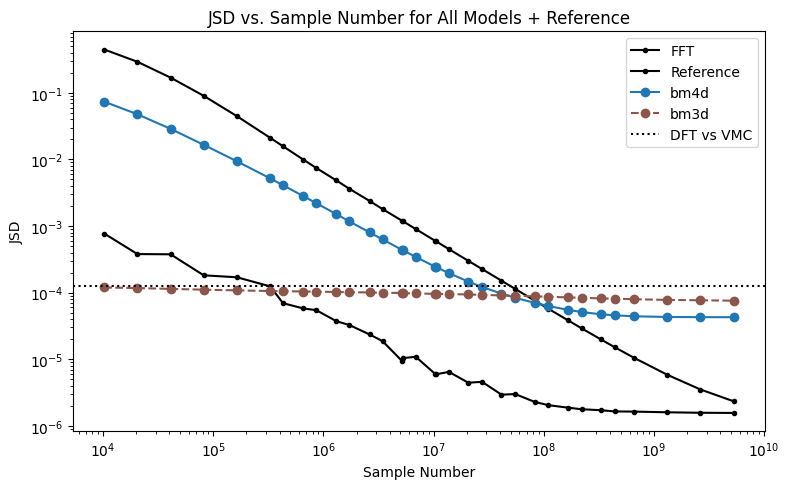

In [24]:
# ================= Plot =================
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)
plt.figure(figsize=(8, 5))
x_values, y_values = zip(*model_results_FFT)
# === Plot ===
logging.getLogger('matplotlib').setLevel(logging.WARNING)
plt.figure(figsize=(8, 5))

plt.loglog(x_values, y_values,
           marker=".",             # Dot markers
           linestyle="-",          # Solid connecting line
           color="black", 
           label="FFT")
colors = plt.cm.tab10(np.linspace(0, 1, len(models) + 1))  # +1 for ref

# Plot reference first
plt.loglog(results_array_ref[:, 0], results_array_ref[:, 1],
           marker=".", linestyle="-", color="black", label="Reference")

# Plot each model
for color, model_name in zip(colors, models):
    results_array = np.array(sorted(results_dict[model_name], key=lambda x: x[0]))
    linestyle = "--" if model_name in ["CAE", "bm3d"] else "-"  # dotted for some
    plt.loglog(results_array[:, 0], results_array[:, 1],
               marker="o", linestyle=linestyle, label=model_name, color=color)

plt.xlabel("Sample Number")
plt.ylabel("JSD")
plt.axhline(DFT_vs_VMC, color="black", linestyle=":", label="DFT vs VMC")
plt.title("JSD vs. Sample Number for All Models + Reference")
plt.legend()
plt.tight_layout()
plt.show()


In [25]:
import matplotlib
matplotlib.use('Agg')  # Prevents backend errors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import logging

logging.getLogger('matplotlib').setLevel(logging.WARNING)

# --- 1. Filter models and prepare data for CSV ---

# Exclude 'nature' from the list of models
filtered_models = [m for m in models if m.lower() != 'nature']

# Build a unified DataFrame aligning all data by "Samples"
# 1. Reference (Noisy VMC)
df = pd.DataFrame(results_array_ref, columns=["Samples", "Noisy_VMC"])

# 2. FFT
fft_df = pd.DataFrame(model_results_FFT, columns=["Samples", "FFT"])
df = pd.merge(df, fft_df, on="Samples", how="outer")

# 3. All other models
for model_name in filtered_models:
    model_data = np.array(sorted(results_dict[model_name], key=lambda x: x[0]))
    temp_df = pd.DataFrame(model_data, columns=["Samples", model_name])
    df = pd.merge(df, temp_df, on="Samples", how="outer")

# Sort by samples and save to CSV
df = df.sort_values("Samples").reset_index(drop=True)
csv_filename = "image_models_performance.csv"
df.to_csv(csv_filename, index=False)
print(f"Data saved to {csv_filename}")


# --- 2. Plotting with Publication Settings ---
plt.rcParams.update({
    'font.size': 14, 
    'font.family': 'serif',
    'axes.labelsize': 16,
    'axes.linewidth': 1.5,
    'xtick.major.size': 7,
    'xtick.major.width': 1.5,
    'ytick.major.size': 7,
    'ytick.major.width': 1.5,
    'legend.frameon': True,
    'legend.edgecolor': 'black',
    'legend.fontsize': 12
})

fig, ax = plt.subplots(figsize=(10, 8))

# Plot Reference (Noisy VMC)
ax.plot(df["Samples"], df["Noisy_VMC"], marker="o", linestyle="--", color="red", label="Noisy VMC", alpha=0.7, markersize=8)

# Plot FFT
ax.plot(df["Samples"], df["FFT"], marker="D", linestyle="-", color="magenta", label="FFT", linewidth=2.5, markersize=8)

# Generate colors for the remaining image models
colors = plt.cm.tab10(np.linspace(0, 1, len(filtered_models)))

# Plot filtered models
for color, model_name in zip(colors, filtered_models):
    linestyle = "--" if model_name in ["CAE", "bm3d"] else "-"
    ax.plot(df["Samples"], df[model_name], marker="s", linestyle=linestyle, label=model_name, color=color, linewidth=2.5, markersize=8)

# DFT Baseline
ax.axhline(DFT_vs_VMC, color="black", linestyle=":", label="DFT Baseline", linewidth=2)

# Formatting
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of VMC Samples', fontweight='bold', labelpad=10)
ax.set_ylabel(r'$D_{JS}$ (Jensen-Shannon Divergence)', fontweight='bold', labelpad=10)
ax.legend(loc='best')
ax.grid(False)

plt.tight_layout()

# --- 3. Save Outputs ---
output_base = "image_models_denoising_convergence"
plt.savefig(f"{output_base}.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{output_base}.pdf", bbox_inches='tight')

print(f"Publication-ready plots saved as {output_base}.png and {output_base}.pdf")

Data saved to image_models_performance.csv
Publication-ready plots saved as image_models_denoising_convergence.png and image_models_denoising_convergence.pdf


In [26]:
print("here")

here
